In [98]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

# **DATASET Creation**


In [99]:
DATA_PATH = r"C:\Users\kevin\Desktop\F1 Project\data"

In [100]:
results = pd.read_csv(
    f"{DATA_PATH}/results_2008_2026.csv"
)

qualifying = pd.read_csv(
    f"{DATA_PATH}/qualifying_2008_2026.csv"
)

print(results.shape)
print(qualifying.shape)

(7733, 9)
(7706, 7)


In [101]:
master = results.merge(
    qualifying,
    on=[
        "race_id",
        "driver_id",
        "constructor_id"
    ],
    how="left",
    suffixes=("", "_quali")
)

print(master.shape)
master.head()

(7733, 13)


,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,position_quali,q1,q2,q3
0,2008_1,hamilton,mclaren,1,1,1,10.0,58,Finished,1.0,1:26.572,1:25.187,1:26.714
1,2008_1,heidfeld,bmw_sauber,5,2,2,8.0,58,Finished,5.0,1:25.960,1:25.518,1:27.236
2,2008_1,rosberg,williams,7,3,3,6.0,58,Finished,7.0,1:26.295,1:26.059,1:28.687
3,2008_1,alonso,renault,11,4,4,5.0,58,Finished,12.0,1:26.907,1:26.188,\N
4,2008_1,kovalainen,mclaren,3,5,5,4.0,58,Finished,3.0,1:25.664,1:25.452,1:27.079


In [102]:
master.isnull().sum()

race_id            0
driver_id          0
constructor_id     0
grid               0
position           0
position_order     0
points             0
laps               0
status             0
position_quali    38
q1                38
q2                38
q3                38
dtype: int64

#**CLEANING**


In [103]:
numeric_cols = [
    "grid",
    "position",
    "position_order",
    "points",
    "laps"
]

for col in numeric_cols:

    master[col] = pd.to_numeric(
        master[col],
        errors="coerce"
    )

In [104]:
master["winner"] = (
    master["position_order"] == 1
).astype(int)

In [105]:
master["podium"] = (
    master["position_order"] <= 3
).astype(int)

In [106]:
master["dnf"] = (
    master["status"] != "Finished"
).astype(int)

#**QUALIFYING FEATURES**

In [107]:
def time_to_seconds(x):

    if pd.isna(x):
        return np.nan

    try:

        mins, secs = str(x).split(":")

        return (
            int(mins) * 60
            + float(secs)
        )

    except:

        return np.nan

In [108]:
for col in ["q1", "q2", "q3"]:

    master[f"{col}_sec"] = (
        master[col]
        .apply(time_to_seconds)
    )

In [109]:
master["best_quali_time"] = master[
    ["q1_sec", "q2_sec", "q3_sec"]
].min(axis=1)

In [110]:
master.rename(
    columns={
        "position_quali":
        "qualifying_position"
    },
    inplace=True,
    errors="ignore"
)

In [111]:
master.columns

Index(['race_id', 'driver_id', 'constructor_id', 'grid', 'position',
       'position_order', 'points', 'laps', 'status', 'qualifying_position',
       'q1', 'q2', 'q3', 'winner', 'podium', 'dnf', 'q1_sec', 'q2_sec',
       'q3_sec', 'best_quali_time'],
      dtype='str')

In [112]:
master

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,qualifying_position,q1,q2,q3,winner,podium,dnf,q1_sec,q2_sec,q3_sec,best_quali_time
0,2008_1,hamilton,mclaren,1.0,1.0,1,10.0,58,Finished,1.0,1:26.572,1:25.187,1:26.714,1,1,0,86.572,85.187,86.714,85.187
1,2008_1,heidfeld,bmw_sauber,5.0,2.0,2,8.0,58,Finished,5.0,1:25.960,1:25.518,1:27.236,0,1,0,85.960,85.518,87.236,85.518
2,2008_1,rosberg,williams,7.0,3.0,3,6.0,58,Finished,7.0,1:26.295,1:26.059,1:28.687,0,1,0,86.295,86.059,88.687,86.059
3,2008_1,alonso,renault,11.0,4.0,4,5.0,58,Finished,12.0,1:26.907,1:26.188,\N,0,0,0,86.907,86.188,NaN,86.188
4,2008_1,kovalainen,mclaren,3.0,5.0,5,4.0,58,Finished,3.0,1:25.664,1:25.452,1:27.079,0,0,0,85.664,85.452,87.079,85.452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728,2026_5,norris,mclaren,3.0,18.0,18,0.0,38,Gearbox,3.0,1:13.503,1:13.049,1:12.729,0,0,1,73.503,73.049,72.729,72.729
7729,2026_5,russell,mercedes,1.0,19.0,19,0.0,29,Engine,1.0,1:13.953,1:13.079,1:12.578,0,0,1,73.953,73.079,72.578,72.578
7730,2026_5,alonso,aston_martin,19.0,20.0,20,0.0,23,Seat,19.0,1:15.196,\N,\N,0,0,1,75.196,NaN,NaN,75.196
7731,2026_5,albon,williams,18.0,21.0,21,0.0,11,Collision,18.0,1:14.851,\N,\N,0,0,1,74.851,NaN,NaN,74.851


#**SEASON AND ROUNDS**


In [113]:
master["season"] = (
    master["race_id"]
    .str.split("_")
    .str[0]
    .astype(int)
)


In [114]:
master["round"] = (
    master["race_id"]
    .str.split("_")
    .str[1]
    .astype(int)
)

In [115]:
master = master.sort_values(
    [
        "season",
        "round"
    ]
).reset_index(drop=True)

In [116]:
master[
    [
        "race_id",
        "season",
        "round"
    ]
].head(20)

,race_id,season,round
0,2008_1,2008,1
1,2008_1,2008,1
2,2008_1,2008,1
3,2008_1,2008,1
4,2008_1,2008,1
5,2008_1,2008,1
6,2008_1,2008,1
7,2008_1,2008,1
8,2008_1,2008,1
9,2008_1,2008,1


#**CHECKPOINT**

In [117]:
master.to_csv(
    f"{DATA_PATH}/master_v1.csv",
    index=False
)

print("saved")

saved


In [118]:
print(master.shape)

master.head()

(7733, 22)


,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,qualifying_position,q1,q2,q3,winner,podium,dnf,q1_sec,q2_sec,q3_sec,best_quali_time,season,round
0,2008_1,hamilton,mclaren,1.0,1.0,1,10.0,58,Finished,1.0,1:26.572,1:25.187,1:26.714,1,1,0,86.572,85.187,86.714,85.187,2008,1
1,2008_1,heidfeld,bmw_sauber,5.0,2.0,2,8.0,58,Finished,5.0,1:25.960,1:25.518,1:27.236,0,1,0,85.960,85.518,87.236,85.518,2008,1
2,2008_1,rosberg,williams,7.0,3.0,3,6.0,58,Finished,7.0,1:26.295,1:26.059,1:28.687,0,1,0,86.295,86.059,88.687,86.059,2008,1
3,2008_1,alonso,renault,11.0,4.0,4,5.0,58,Finished,12.0,1:26.907,1:26.188,\N,0,0,0,86.907,86.188,NaN,86.188,2008,1
4,2008_1,kovalainen,mclaren,3.0,5.0,5,4.0,58,Finished,3.0,1:25.664,1:25.452,1:27.079,0,0,0,85.664,85.452,87.079,85.452,2008,1


In [119]:
master.drop(columns=["position"], inplace=True)

#**DRIVER STATS**

In [120]:
master = master.sort_values(
    ["driver_id","season","round"]
)

In [121]:
master["driver_avg_finish_last3"] = (
    master.groupby("driver_id")["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3, min_periods=1)
         .mean()
    )
)#change number of races module to check output

In [122]:
master["driver_avg_finish_last5"] = (
    master.groupby("driver_id")["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=1)
         .mean()
    )
)

In [123]:
master["driver_avg_finish_last10"] = (
    master.groupby("driver_id")["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(10, min_periods=1)
         .mean()
    )
)

In [124]:
master["driver_prev_wins"] = (
    master.groupby("driver_id")["winner"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [125]:
master["driver_prev_podiums"] = (
    master.groupby("driver_id")["podium"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [126]:
master["driver_dnf_rate"] = (
    master.groupby("driver_id")["dnf"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

#**CONSTRUCTOR STATUS**

In [127]:
master["constructor_avg_finish_last5"] = (
    master.groupby("constructor_id")["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=1)
         .mean()
    )
)

In [128]:
master["constructor_prev_wins"] = (
    master.groupby("constructor_id")["winner"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [129]:
master["constructor_prev_podiums"] = (
    master.groupby("constructor_id")["podium"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

#**MOMENTUM OF THE RACER**

In [130]:
master["finish_change"] = (
    master.groupby("driver_id")["position_order"]
    .diff()
)

In [131]:
master["momentum_last3"] = (
    master.groupby("driver_id")["finish_change"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3, min_periods=1)
         .mean()
    )
)

#**QUALIFYING STATS**

In [132]:
master["avg_quali_last5"] = (
    master.groupby("driver_id")["qualifying_position"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=1)
         .mean()
    )
)

In [133]:
master["quali_change"] = (
    master.groupby("driver_id")["qualifying_position"]
    .diff()
)

In [134]:
print(master.shape)

master.columns.tolist()

(7733, 34)


['race_id',
 'driver_id',
 'constructor_id',
 'grid',
 'position_order',
 'points',
 'laps',
 'status',
 'qualifying_position',
 'q1',
 'q2',
 'q3',
 'winner',
 'podium',
 'dnf',
 'q1_sec',
 'q2_sec',
 'q3_sec',
 'best_quali_time',
 'season',
 'round',
 'driver_avg_finish_last3',
 'driver_avg_finish_last5',
 'driver_avg_finish_last10',
 'driver_prev_wins',
 'driver_prev_podiums',
 'driver_dnf_rate',
 'constructor_avg_finish_last5',
 'constructor_prev_wins',
 'constructor_prev_podiums',
 'finish_change',
 'momentum_last3',
 'avg_quali_last5',
 'quali_change']

In [135]:
master[
[
"driver_id",
"race_id",
"driver_avg_finish_last3",
"driver_avg_finish_last5",
"driver_prev_wins",
"constructor_avg_finish_last5"
]
].head(100)

,driver_id,race_id,driver_avg_finish_last3,driver_avg_finish_last5,driver_prev_wins,constructor_avg_finish_last5
5320,aitken,2020_16,NaN,NaN,NaN,NaN
4598,albon,2019_1,NaN,NaN,NaN,NaN
4613,albon,2019_2,14.000000,14.0,0.0,14.0
4634,albon,2019_3,11.500000,11.5,0.0,11.5
4655,albon,2019_4,11.000000,11.0,0.0,11.0
...,...,...,...,...,...,...
6935,albon,2024_14,12.666667,14.6,0.0,14.6
6957,albon,2024_15,11.666667,13.6,0.0,13.6
6972,albon,2024_16,13.333333,12.8,0.0,12.8
6990,albon,2024_17,11.666667,11.6,0.0,11.6


In [136]:
master

,race_id,driver_id,constructor_id,grid,position_order,points,laps,status,qualifying_position,q1,q2,q3,winner,podium,dnf,q1_sec,q2_sec,q3_sec,best_quali_time,season,round,driver_avg_finish_last3,driver_avg_finish_last5,driver_avg_finish_last10,driver_prev_wins,driver_prev_podiums,driver_dnf_rate,constructor_avg_finish_last5,constructor_prev_wins,constructor_prev_podiums,finish_change,momentum_last3,avg_quali_last5,quali_change
5320,2020_16,aitken,williams,17.0,16,0.0,87,Finished,18.0,0:54.892,\N,\N,0,0,0,54.892,NaN,NaN,54.892,2020,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4598,2019_1,albon,toro_rosso,13.0,14,0.0,57,+1 Lap,13.0,1:22.757,1:22.636,\N,0,0,1,82.757,82.636,NaN,82.636,2019,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4613,2019_2,albon,toro_rosso,12.0,9,2.0,57,Finished,12.0,1:29.514,1:29.513,\N,0,0,0,89.514,89.513,NaN,89.513,2019,2,14.000000,14.0,14.0,0.0,0.0,1.000000,14.0,0.0,0.0,-5.0,NaN,13.0,-1.0
4634,2019_3,albon,toro_rosso,0.0,10,1.0,55,+1 Lap,NaN,NaN,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,2019,3,11.500000,11.5,11.5,0.0,0.0,0.500000,11.5,0.0,0.0,1.0,-5.000000,12.5,NaN
4655,2019_4,albon,toro_rosso,11.0,11,0.0,50,+1 Lap,12.0,1:42.154,1:42.494,\N,0,0,1,102.154,102.494,NaN,102.154,2019,4,11.000000,11.0,11.0,0.0,0.0,0.666667,11.0,0.0,0.0,1.0,-2.000000,12.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7058,2024_20,zhou,sauber,19.0,15,0.0,70,+1 Lap,20.0,1:18.072,\N,\N,0,0,1,78.072,NaN,NaN,78.072,2024,20,16.000000,17.2,17.2,0.0,0.0,0.603175,17.2,0.0,5.0,-4.0,0.333333,19.2,0.0
7078,2024_21,zhou,sauber,19.0,15,0.0,69,Finished,20.0,1:32.263,\N,\N,0,0,0,92.263,NaN,NaN,92.263,2024,21,16.333333,16.2,17.4,0.0,0.0,0.609375,16.2,0.0,5.0,0.0,0.333333,19.6,0.0
7096,2024_22,zhou,sauber,13.0,13,0.0,50,Finished,13.0,1:34.079,1:33.566,\N,0,0,0,94.079,93.566,NaN,93.566,2024,22,16.333333,15.6,17.2,0.0,0.0,0.600000,15.6,0.0,5.0,-2.0,0.000000,19.6,-7.0
7111,2024_23,zhou,sauber,12.0,8,4.0,57,Finished,12.0,1:22.103,1:21.501,\N,0,0,0,82.103,81.501,NaN,81.501,2024,23,14.333333,15.4,16.7,0.0,0.0,0.590909,15.4,0.0,5.0,-5.0,-2.000000,18.6,-1.0


In [137]:
races = pd.read_csv(f"{DATA_PATH}/races.csv")

print(races["year"].min())
print(races["year"].max())

display(
    races[
        ["year","round","name","circuitId"]
    ].tail(30)
)

1950
2026


,year,round,name,circuitId
1141,2025,17,Azerbaijan Grand Prix,73
1142,2025,18,Singapore Grand Prix,15
1143,2025,19,United States Grand Prix,69
1144,2025,20,Mexico City Grand Prix,32
1145,2025,21,São Paulo Grand Prix,18
1146,2025,22,Las Vegas Grand Prix,80
1147,2025,23,Qatar Grand Prix,78
1148,2025,24,Abu Dhabi Grand Prix,24
1149,2026,1,Australian Grand Prix,1
1150,2026,2,Chinese Grand Prix,17


In [138]:
races = pd.read_csv(
    f"{DATA_PATH}/races.csv"
)

circuits = pd.read_csv(
    f"{DATA_PATH}/circuits.csv"
)

races = races.merge(
    circuits[
        [
            "circuitId",
            "name",
            "country"
        ]
    ],
    on="circuitId",
    how="left",
    suffixes=("", "_circuit")
)

races["race_id"] = (
    races["year"].astype(str)
    + "_"
    + races["round"].astype(str)
)

race_lookup = races[
    [
        "race_id",
        "name",
        "circuitId",
        "name_circuit",
        "country"
    ]
]

race_lookup.head()

,race_id,name,circuitId,name_circuit,country
0,2009_1,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Australia
1,2009_2,Malaysian Grand Prix,2,Sepang International Circuit,Malaysia
2,2009_3,Chinese Grand Prix,17,Shanghai International Circuit,China
3,2009_4,Bahrain Grand Prix,3,Bahrain International Circuit,Bahrain
4,2009_5,Spanish Grand Prix,4,Circuit de Barcelona-Catalunya,Spain


In [139]:
master = master.merge(
    race_lookup,
    on="race_id",
    how="left"
)

print(master.shape)

(7733, 38)


In [140]:
master = master.sort_values(
    [
        "season",
        "round"
    ]
).reset_index(drop=True)

#**DRIVER TRACK HISTORY**


In [141]:
master["driver_track_avg_finish"] = (
    master.groupby(
        ["driver_id", "circuitId"]
    )["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

In [142]:
master["driver_track_wins"] = (
    master.groupby(
        ["driver_id", "circuitId"]
    )["winner"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [143]:
master["driver_track_podiums"] = (
    master.groupby(
        ["driver_id", "circuitId"]
    )["podium"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)


In [144]:
master["driver_track_dnf_rate"] = (
    master.groupby(
        ["driver_id", "circuitId"]
    )["dnf"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

#**CONSTRUCTORS TRACK HISTORY**

In [145]:
master["constructor_track_avg_finish"] = (
    master.groupby(
        ["constructor_id", "circuitId"]
    )["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

In [146]:
master["constructor_track_wins"] = (
    master.groupby(
        ["constructor_id", "circuitId"]
    )["winner"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [147]:
master["constructor_track_dnf_rate"] = (
    master.groupby(
        ["constructor_id", "circuitId"]
    )["dnf"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

#**DRIVER EXPERIENCE**

In [148]:
master["driver_prev_races"] = (
    master.groupby("driver_id")
    .cumcount()
)

In [149]:
master["career_win_rate"] = (
    master.groupby("driver_id")["winner"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

In [150]:
master["career_podium_rate"] = (
    master.groupby("driver_id")["podium"]
    .transform(
        lambda x:
        x.shift(1)
         .expanding()
         .mean()
    )
)

#**DRIVER MOMENTUM**

In [151]:
master["driver_momentum"] = (
    master.groupby("driver_id")["position_order"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=2)
         .apply(
             lambda y:
             np.polyfit(
                 range(len(y)),
                 y,
                 1
             )[0]
         )
    )
)

In [152]:
important_cols = [

    "driver_id",
    "race_id",

    "driver_track_avg_finish",
    "driver_track_wins",

    "driver_track_dnf_rate",

    "constructor_track_avg_finish",

    "driver_prev_races",

    "career_win_rate",

    "driver_momentum"

]

master[important_cols].tail(20)

,driver_id,race_id,driver_track_avg_finish,driver_track_wins,driver_track_dnf_rate,constructor_track_avg_finish,driver_prev_races,career_win_rate,driver_momentum
7713,antonelli,2026_5,3.000000,0.0,0.000000,5.392857,28,0.107143,-2.900000e+00
7714,arvid_lindblad,2026_5,NaN,NaN,NaN,14.250000,4,0.000000,NaN
7715,bearman,2026_5,11.000000,0.0,1.000000,13.500000,31,0.000000,1.300000e+00
7716,bortoleto,2026_5,14.000000,0.0,1.000000,NaN,28,0.000000,6.000000e-01
7717,bottas,2026_5,6.500000,0.0,0.100000,NaN,251,0.039841,-3.609141e-16
7718,colapinto,2026_5,13.000000,0.0,1.000000,10.250000,31,0.000000,-2.200000e+00
7719,gasly,2026_5,11.500000,0.0,0.500000,9.777778,182,0.005495,1.000000e-01
7720,hadjar,2026_5,16.000000,0.0,1.000000,6.133333,28,0.000000,2.000000e-01
7721,hamilton,2026_5,6.000000,6.0,0.200000,7.066667,367,0.275204,-2.434988e-16
7722,hulkenberg,2026_5,10.250000,0.0,0.583333,13.000000,258,0.000000,9.000000e-01


In [153]:
print(master.shape)

(7733, 49)


#**CHAMPIONSHIP STANDINGS**

#*DRIVER CHAMPIONSHIP*

In [154]:
master = master.sort_values(
    ["season", "round"]
).reset_index(drop=True)

In [155]:
master["driver_points_before_race"] = (
    master.groupby(
        ["season", "driver_id"]
    )["points"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [156]:
master["driver_rank_before_race"] = (
    master.groupby(
        ["season", "race_id"]
    )["driver_points_before_race"]
    .rank(
        ascending=False,
        method="dense"
    )
)

#*CONSTRUCTORS CHAMPIONSHIP*

In [157]:
master["constructor_points_before_race"] = (
    master.groupby(
        ["season", "constructor_id"]
    )["points"]
    .transform(
        lambda x:
        x.shift(1)
         .cumsum()
    )
)

In [158]:
master["constructor_rank_before_race"] = (
    master.groupby(
        ["season", "race_id"]
    )["constructor_points_before_race"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [159]:
import pandas as pd

for col in feature_cols:

    if pd.api.types.is_numeric_dtype(master[col]):

        master[col] = master[col].fillna(
            master[col].median()
        )

#*CHAMPIONSHIP FEATURES*

In [160]:
master = master.sort_values(
    ["season", "round"]
).reset_index(drop=True)

master["driver_points_before_race"] = (
    master.groupby(
        ["season", "driver_id"]
    )["points"]
    .transform(
        lambda x: x.shift(1).cumsum()
    )
)

In [161]:
master["driver_rank_before_race"] = (
    master.groupby(
        ["season", "race_id"]
    )["driver_points_before_race"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [162]:
master["constructor_points_before_race"] = (
    master.groupby(
        ["season", "constructor_id"]
    )["points"]
    .transform(
        lambda x: x.shift(1).cumsum()
    )
)

In [163]:
master["constructor_rank_before_race"] = (
    master.groupby(
        ["season", "race_id"]
    )["constructor_points_before_race"]
    .rank(
        ascending=False,
        method="dense"
    )
)

#**RECENT FORM**

In [164]:
master["driver_points_last5"] = (
    master.groupby("driver_id")["points"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=1)
         .sum()
    )
)

In [165]:
master["driver_points_last10"] = (
    master.groupby("driver_id")["points"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(10, min_periods=1)
         .sum()
    )
)

In [166]:
master["constructor_points_last5"] = (
    master.groupby("constructor_id")["points"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=1)
         .sum()
    )
)

#**QUALIFYING POWER**

In [167]:
master["grid_gain"] = (
    master["qualifying_position"]
    - master["grid"]
)

In [168]:
master["avg_quali_last3"] = (
    master.groupby("driver_id")["qualifying_position"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3, min_periods=1)
         .mean()
    )
)

In [169]:
master["avg_quali_last5"] = (
    master.groupby("driver_id")["qualifying_position"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(5, min_periods=1)
         .mean()
    )
)

In [170]:
master["previous_poles"] = (
    master.groupby("driver_id")
    ["qualifying_position"]
    .transform(
        lambda x:
        (x.shift(1) == 1)
        .cumsum()
    )
)

#**PREDICTION**

In [171]:
master["winner"].value_counts()

winner
0    7364
1     369
Name: count, dtype: int64

In [172]:
master["podium"].value_counts()

podium
0    6626
1    1107
Name: count, dtype: int64

In [173]:
master["top10"] = (
    master["position_order"] <= 10
).astype(int)

In [174]:
#Filling Missing NA
numeric_cols = master.select_dtypes(
    include=["number"]
).columns

for col in numeric_cols:

    master[col] = master[col].fillna(
        master[col].median()
    )

In [175]:
master.to_csv(
    "f1_feature_engineered.csv",
    index=False
)

print(master.shape)

(7733, 60)


In [176]:
print(master.shape)

print(master.columns.tolist())

(7733, 60)
['race_id', 'driver_id', 'constructor_id', 'grid', 'position_order', 'points', 'laps', 'status', 'qualifying_position', 'q1', 'q2', 'q3', 'winner', 'podium', 'dnf', 'q1_sec', 'q2_sec', 'q3_sec', 'best_quali_time', 'season', 'round', 'driver_avg_finish_last3', 'driver_avg_finish_last5', 'driver_avg_finish_last10', 'driver_prev_wins', 'driver_prev_podiums', 'driver_dnf_rate', 'constructor_avg_finish_last5', 'constructor_prev_wins', 'constructor_prev_podiums', 'finish_change', 'momentum_last3', 'avg_quali_last5', 'quali_change', 'name', 'circuitId', 'name_circuit', 'country', 'driver_track_avg_finish', 'driver_track_wins', 'driver_track_podiums', 'driver_track_dnf_rate', 'constructor_track_avg_finish', 'constructor_track_wins', 'constructor_track_dnf_rate', 'driver_prev_races', 'career_win_rate', 'career_podium_rate', 'driver_momentum', 'driver_points_before_race', 'driver_rank_before_race', 'constructor_points_before_race', 'constructor_rank_before_race', 'driver_points_last5'

In [177]:
master[
[
    "driver_id",
    "race_id",
    "driver_points_before_race",
    "driver_rank_before_race",
    "constructor_rank_before_race",
    "driver_points_last5",
    "avg_quali_last5",
    "driver_track_wins"
]
].tail(20)

,driver_id,race_id,driver_points_before_race,driver_rank_before_race,constructor_rank_before_race,driver_points_last5,avg_quali_last5,driver_track_wins
7713,antonelli,2026_5,93.0,1.0,2.0,93.0,3.8,0.0
7714,arvid_lindblad,2026_5,4.0,12.0,12.0,4.0,12.5,0.0
7715,bearman,2026_5,16.0,8.0,11.0,16.0,12.6,0.0
7716,bortoleto,2026_5,2.0,13.0,14.0,2.0,12.6,0.0
7717,bottas,2026_5,0.0,15.0,15.0,0.0,17.4,0.0
7718,colapinto,2026_5,5.0,11.0,9.0,5.0,14.2,0.0
7719,gasly,2026_5,15.0,9.0,7.0,15.0,11.2,0.0
7720,hadjar,2026_5,4.0,12.0,8.0,4.0,7.6,0.0
7721,hamilton,2026_5,41.0,4.0,4.0,45.0,7.6,6.0
7722,hulkenberg,2026_5,0.0,15.0,14.0,2.0,12.6,0.0


#**RELATIVE RACE FEATURES**

In [178]:
master["quali_advantage"] = (
    master.groupby("race_id")["qualifying_position"]
    .transform("mean")
    - master["qualifying_position"]
)

In [179]:
master["grid_advantage"] = (
    master.groupby("race_id")["grid"]
    .transform("mean")
    - master["grid"]
)

In [180]:
master["points_advantage"] = (
    master["driver_points_before_race"]
    -
    master.groupby("race_id")
    ["driver_points_before_race"]
    .transform("mean")
)

#**FEATURE SELECTION**

In [181]:
DROP_COLS = [

    # targets
    "winner",
    "podium",
    "top10",

    # post-race outcome
    "position_order",
    "points",
    "status",

    # identifiers
    "race_id",
    "driver_id",
    "constructor_id",

    # raw qualifying strings
    "q1",
    "q2",
    "q3",

    # text columns
    "name",
    "name_circuit",
    "country"
]

In [182]:
FEATURES = [
    c for c in master.columns
    if c not in DROP_COLS
]

In [183]:
print(len(FEATURES))
print(FEATURES)

48
['grid', 'laps', 'qualifying_position', 'dnf', 'q1_sec', 'q2_sec', 'q3_sec', 'best_quali_time', 'season', 'round', 'driver_avg_finish_last3', 'driver_avg_finish_last5', 'driver_avg_finish_last10', 'driver_prev_wins', 'driver_prev_podiums', 'driver_dnf_rate', 'constructor_avg_finish_last5', 'constructor_prev_wins', 'constructor_prev_podiums', 'finish_change', 'momentum_last3', 'avg_quali_last5', 'quali_change', 'circuitId', 'driver_track_avg_finish', 'driver_track_wins', 'driver_track_podiums', 'driver_track_dnf_rate', 'constructor_track_avg_finish', 'constructor_track_wins', 'constructor_track_dnf_rate', 'driver_prev_races', 'career_win_rate', 'career_podium_rate', 'driver_momentum', 'driver_points_before_race', 'driver_rank_before_race', 'constructor_points_before_race', 'constructor_rank_before_race', 'driver_points_last5', 'driver_points_last10', 'constructor_points_last5', 'grid_gain', 'avg_quali_last3', 'previous_poles', 'quali_advantage', 'grid_advantage', 'points_advantage']


#**TRAIN TEST VALIDATE SPLITING**

In [184]:
train = master[
    master["season"] <= 2022
].copy()

valid = master[
    (master["season"] >= 2023)
    &
    (master["season"] <= 2024)
].copy()

test = master[
    master["season"] >= 2025
].copy()

In [185]:
X_train = train[FEATURES]
y_train = train["winner"]

X_valid = valid[FEATURES]
y_valid = valid["winner"]

X_test = test[FEATURES]
y_test = test["winner"]

In [186]:
print(y_train.value_counts(normalize=True))

winner
0    0.952771
1    0.047229
Name: proportion, dtype: float64


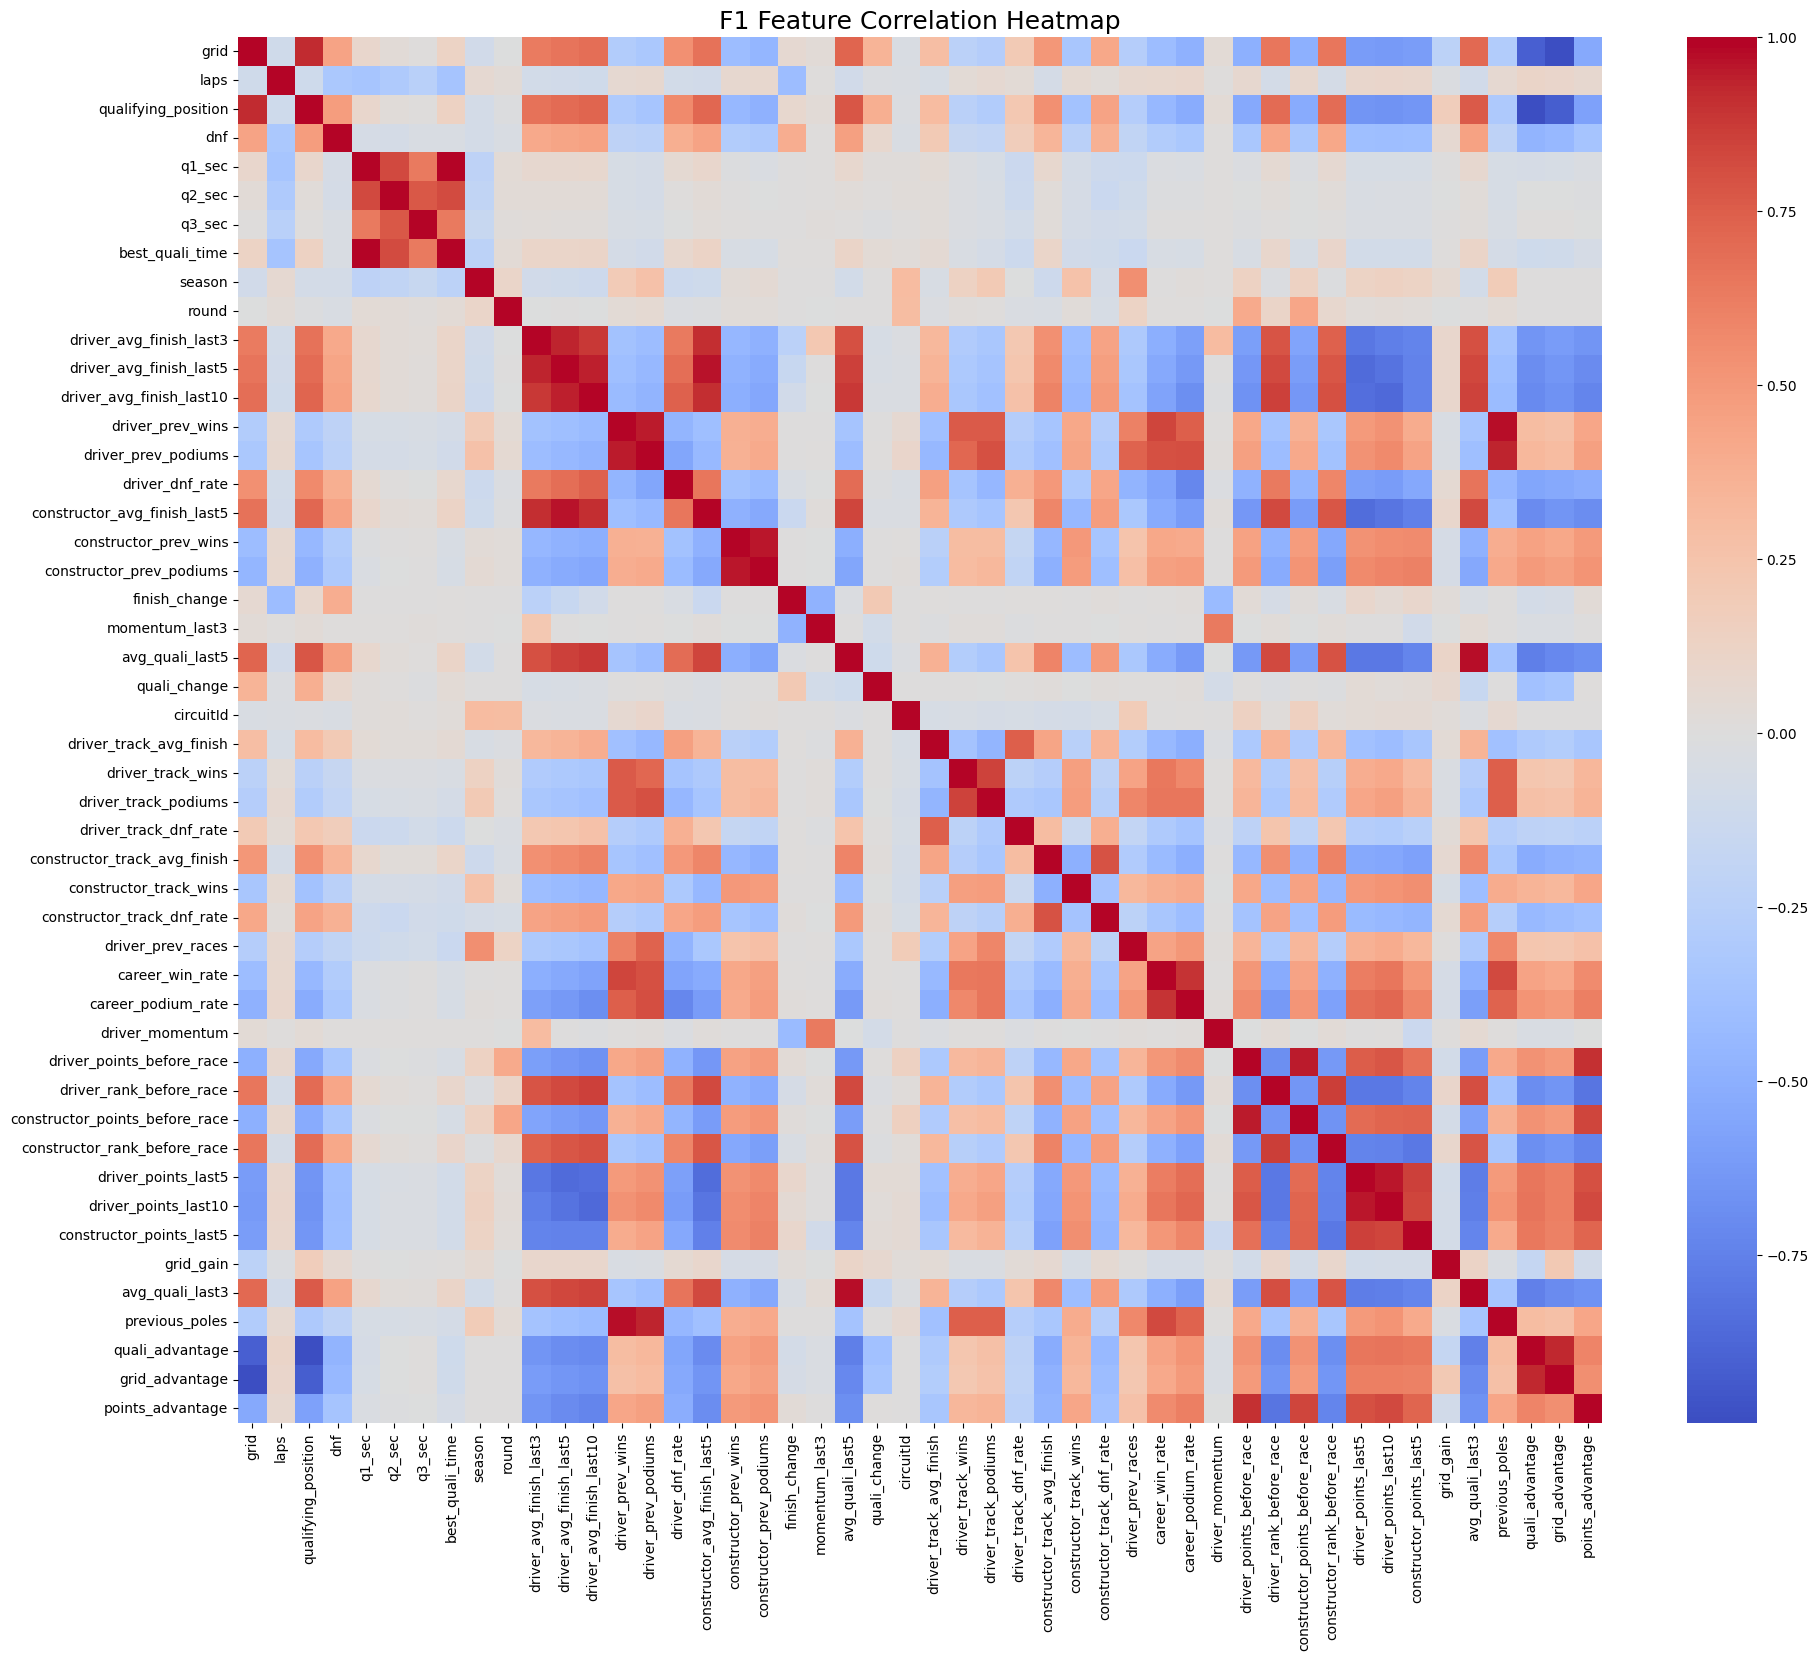

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = master[FEATURES].corr()

plt.figure(figsize=(22,18))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "F1 Feature Correlation Heatmap",
    fontsize=18
)

plt.show()

#MODEL SELECTION

#*RANDOM FOREST MODEL*

In [189]:
from sklearn.ensemble import RandomForestClassifier

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=3, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report

preds = rf.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       560
           1       0.62      0.86      0.72        29

    accuracy                           0.97       589
   macro avg       0.81      0.92      0.85       589
weighted avg       0.97      0.97      0.97       589



In [ ]:
imp = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
})

imp = imp.sort_values(
    "importance",
    ascending=False
)

print(
    imp.head(30)
)

                         feature  importance
2            qualifying_position    0.123177
45               quali_advantage    0.096524
19                 finish_change    0.085603
0                           grid    0.080673
46                grid_advantage    0.068745
21               avg_quali_last5    0.048410
43               avg_quali_last3    0.035145
17         constructor_prev_wins    0.032219
36       driver_rank_before_race    0.029699
16  constructor_avg_finish_last5    0.029487
12      driver_avg_finish_last10    0.029053
11       driver_avg_finish_last5    0.027520
40          driver_points_last10    0.027383
38  constructor_rank_before_race    0.024515
3                            dnf    0.022127
47              points_advantage    0.021798
39           driver_points_last5    0.020728
32               career_win_rate    0.017872
33            career_podium_rate    0.016102
18      constructor_prev_podiums    0.011820
41      constructor_points_last5    0.010891
10       d

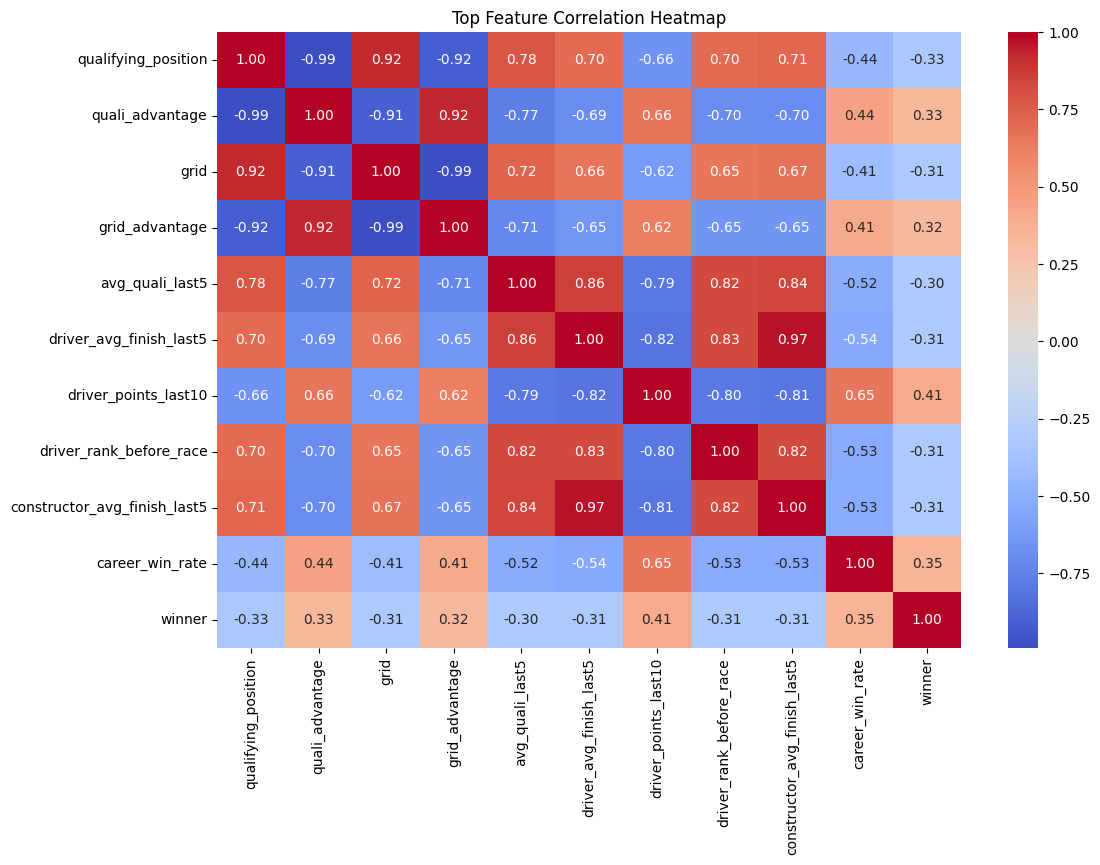

In [ ]:
top_features = [

    "qualifying_position",
    "quali_advantage",
    "grid",
    "grid_advantage",
    "avg_quali_last5",
    "driver_avg_finish_last5",
    "driver_points_last10",
    "driver_rank_before_race",
    "constructor_avg_finish_last5",
    "career_win_rate",
    "winner"

]

plt.figure(figsize=(12,8))

sns.heatmap(
    master[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(
    "Top Feature Correlation Heatmap"
)

plt.show()

#*XGBOOST MODEL*

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [ ]:
scale_pos_weight = (
    len(y_train[y_train == 0])
    /
    len(y_train[y_train == 1])
)

print(scale_pos_weight)

20.1734693877551


In [ ]:
xgb = XGBClassifier(

    n_estimators=1000,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42

)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_preds = xgb.predict(X_test)

xgb_probs = xgb.predict_proba(
    X_test
)[:,1]

In [ ]:
print(
    classification_report(
        y_test,
        xgb_preds
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       560
           1       0.77      0.83      0.80        29

    accuracy                           0.98       589
   macro avg       0.88      0.91      0.89       589
weighted avg       0.98      0.98      0.98       589



In [ ]:
print(
    roc_auc_score(
        y_test,
        xgb_probs
    )
)

0.994642857142857


In [ ]:
print(
    confusion_matrix(
        y_test,
        xgb_preds
    )
)

[[553   7]
 [  5  24]]


In [ ]:
imp_xgb = pd.DataFrame({

    "feature": FEATURES,

    "importance": xgb.feature_importances_

})

imp_xgb = imp_xgb.sort_values(
    "importance",
    ascending=False
)

display(
    imp_xgb.head(30)
)

,feature,importance
2,qualifying_position,0.358681
45,quali_advantage,0.166546
0,grid,0.081851
3,dnf,0.076124
19,finish_change,0.040582
11,driver_avg_finish_last5,0.019491
46,grid_advantage,0.017663
42,grid_gain,0.014480
39,driver_points_last5,0.012339
16,constructor_avg_finish_last5,0.010231


In [ ]:
test["win_probability"] = xgb.predict_proba(
    X_test
)[:,1]

In [ ]:
predicted_winners = (

    test
    .sort_values(
        ["race_id","win_probability"],
        ascending=[True,False]
    )
    .groupby("race_id")
    .head(1)

)

In [ ]:
actual_winners = test[
    test["winner"] == 1
][["race_id","driver_id"]]

In [ ]:
comparison = predicted_winners[
    ["race_id","driver_id"]
].merge(

    actual_winners,

    on="race_id",

    suffixes=(
        "_predicted",
        "_actual"
    )

)

comparison["correct"] = (

    comparison["driver_id_predicted"]

    ==

    comparison["driver_id_actual"]

)

In [ ]:
winner_hit_rate = (

    comparison["correct"]
    .mean()

)

print(
    f"Winner Hit Rate: {winner_hit_rate:.2%}"
)

Winner Hit Rate: 82.76%


In [ ]:
top3_preds = (

    test
    .sort_values(
        ["race_id","win_probability"],
        ascending=[True,False]
    )
    .groupby("race_id")
    .head(3)

)

In [ ]:
top3_results = []

for race in test["race_id"].unique():

    actual = (

        actual_winners[
            actual_winners["race_id"] == race
        ]

        ["driver_id"]

        .iloc[0]
    )

    preds = (

        top3_preds[
            top3_preds["race_id"] == race
        ]

        ["driver_id"]

        .tolist()
    )

    top3_results.append(
        actual in preds
    )

print(
    "Top 3 Hit Rate:",
    np.mean(top3_results)
)

Top 3 Hit Rate: 1.0


#**FOR TIMES WHEN WE DONT HAVE THE QUALIFYING RACE DATA(ie PRE RACE WEEK)

In [ ]:
PRE_QUALI_REMOVE = [

    "qualifying_position",
    "grid",

    "q1_sec",
    "q2_sec",
    "q3_sec",

    "best_quali_time",

    "avg_quali_last3",
    "avg_quali_last5",

    "quali_advantage",

    "grid_advantage",

    "grid_gain",

    "previous_poles",

    "quali_change"

]

In [ ]:
import pandas as pd

pd.DataFrame({

    "feature": FEATURES,
    "importance": xgb.feature_importances_

}).sort_values(
    "importance",
    ascending=False
).head(50)

,feature,importance
2,qualifying_position,0.358681
45,quali_advantage,0.166546
0,grid,0.081851
3,dnf,0.076124
19,finish_change,0.040582
11,driver_avg_finish_last5,0.019491
46,grid_advantage,0.017663
42,grid_gain,0.014480
39,driver_points_last5,0.012339
16,constructor_avg_finish_last5,0.010231


#Retrain a new model in order to accoimodate DNF

In [ ]:
# Remove leakage columns

DROP_COLS = [

    # Targets
    "winner",
    "podium",
    "top10",

    # Post-race outcomes
    "position_order",
    "points",
    "status",

    # Identifiers
    "race_id",
    "driver_id",
    "constructor_id",

    # Raw qualifying strings
    "q1",
    "q2",
    "q3",

    # Text columns
    "name",
    "name_circuit",
    "country",

    # Leakage
    "dnf",
    "laps"
]

FEATURES = [
    c for c in master.columns
    if c not in DROP_COLS
]

print("Number of Features:", len(FEATURES))
print(FEATURES)

Number of Features: 46
['grid', 'qualifying_position', 'q1_sec', 'q2_sec', 'q3_sec', 'best_quali_time', 'season', 'round', 'driver_avg_finish_last3', 'driver_avg_finish_last5', 'driver_avg_finish_last10', 'driver_prev_wins', 'driver_prev_podiums', 'driver_dnf_rate', 'constructor_avg_finish_last5', 'constructor_prev_wins', 'constructor_prev_podiums', 'finish_change', 'momentum_last3', 'avg_quali_last5', 'quali_change', 'circuitId', 'driver_track_avg_finish', 'driver_track_wins', 'driver_track_podiums', 'driver_track_dnf_rate', 'constructor_track_avg_finish', 'constructor_track_wins', 'constructor_track_dnf_rate', 'driver_prev_races', 'career_win_rate', 'career_podium_rate', 'driver_momentum', 'driver_points_before_race', 'driver_rank_before_race', 'constructor_points_before_race', 'constructor_rank_before_race', 'driver_points_last5', 'driver_points_last10', 'constructor_points_last5', 'grid_gain', 'avg_quali_last3', 'previous_poles', 'quali_advantage', 'grid_advantage', 'points_advanta

In [ ]:
train = master[
    master["season"] <= 2022
].copy()

valid = master[
    (master["season"] >= 2023)
    &
    (master["season"] <= 2024)
].copy()

test = master[
    master["season"] >= 2025
].copy()

In [ ]:
X_train = train[FEATURES]
y_train = train["winner"]

X_valid = valid[FEATURES]
y_valid = valid["winner"]

X_test = test[FEATURES]
y_test = test["winner"]

In [ ]:
scale_pos_weight = (
    len(y_train[y_train == 0])
    /
    len(y_train[y_train == 1])
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 20.1734693877551


In [ ]:
from xgboost import XGBClassifier

xgb_clean = XGBClassifier(

    n_estimators=1000,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42

)

xgb_clean.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_preds = xgb_clean.predict(X_test)

xgb_probs = xgb_clean.predict_proba(
    X_test
)[:, 1]

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        xgb_preds
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       560
           1       0.77      0.79      0.78        29

    accuracy                           0.98       589
   macro avg       0.88      0.89      0.88       589
weighted avg       0.98      0.98      0.98       589



In [ ]:
print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        xgb_probs
    )
)

ROC AUC: 0.9942118226600984


In [ ]:
print(
    confusion_matrix(
        y_test,
        xgb_preds
    )
)

[[553   7]
 [  6  23]]


In [ ]:
test_eval = test.copy()

test_eval["win_probability"] = xgb_probs

In [ ]:
predicted_winners = (

    test_eval
    .sort_values(
        ["race_id", "win_probability"],
        ascending=[True, False]
    )
    .groupby("race_id")
    .head(1)

)

In [ ]:
actual_winners = test_eval[
    test_eval["winner"] == 1
][["race_id", "driver_id"]]

In [ ]:
comparison = predicted_winners[
    ["race_id", "driver_id"]
].merge(

    actual_winners,

    on="race_id",

    suffixes=(
        "_predicted",
        "_actual"
    )

)

comparison["correct"] = (

    comparison["driver_id_predicted"]

    ==
    comparison["driver_id_actual"]

)

In [ ]:
winner_hit_rate = (
    comparison["correct"]
    .mean()
)

print(
    f"Winner Hit Rate: {winner_hit_rate:.2%}"
)

Winner Hit Rate: 82.76%


In [ ]:
top3_preds = (

    test_eval
    .sort_values(
        ["race_id", "win_probability"],
        ascending=[True, False]
    )
    .groupby("race_id")
    .head(3)

)

In [ ]:
import numpy as np

top3_results = []

for race in test_eval["race_id"].unique():

    actual = (

        actual_winners[
            actual_winners["race_id"] == race
        ]

        ["driver_id"]

        .iloc[0]
    )

    preds = (

        top3_preds[
            top3_preds["race_id"] == race
        ]

        ["driver_id"]

        .tolist()
    )

    top3_results.append(
        actual in preds
    )

print(
    "Top 3 Hit Rate:",
    np.mean(top3_results)
)

Top 3 Hit Rate: 1.0


In [ ]:
imp_clean = pd.DataFrame({

    "feature": FEATURES,

    "importance": xgb_clean.feature_importances_

})

imp_clean = imp_clean.sort_values(
    "importance",
    ascending=False
)

display(
    imp_clean.head(30)
)

,feature,importance
1,qualifying_position,0.378741
43,quali_advantage,0.202093
0,grid,0.074375
17,finish_change,0.044280
40,grid_gain,0.018293
9,driver_avg_finish_last5,0.017039
14,constructor_avg_finish_last5,0.015027
44,grid_advantage,0.012787
37,driver_points_last5,0.012199
19,avg_quali_last5,0.009849


In [ ]:
print("dnf" in FEATURES)
print("laps" in FEATURES)

False
False


In [ ]:
import pickle

with open(
    "f1_winner_model.pkl",
    "wb"
) as f:

    pickle.dump(
        xgb_clean,
        f
    )

with open(
    "f1_features.pkl",
    "wb"
) as f:

    pickle.dump(
        FEATURES,
        f
    )

In [ ]:
print(len(FEATURES))
print(len(xgb_clean.feature_importances_))

46
46


In [ ]:
imp_clean = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_clean.feature_importances_
})

imp_clean = imp_clean.sort_values(
    "importance",
    ascending=False
)

print(imp_clean.head(30))

                         feature  importance
1            qualifying_position    0.378741
43               quali_advantage    0.202093
0                           grid    0.074375
17                 finish_change    0.044280
40                     grid_gain    0.018293
9        driver_avg_finish_last5    0.017039
14  constructor_avg_finish_last5    0.015027
44                grid_advantage    0.012787
37           driver_points_last5    0.012199
19               avg_quali_last5    0.009849
38          driver_points_last10    0.009272
34       driver_rank_before_race    0.008879
30               career_win_rate    0.008767
4                         q3_sec    0.008398
16      constructor_prev_podiums    0.008349
18                momentum_last3    0.007593
45              points_advantage    0.007562
8        driver_avg_finish_last3    0.007556
5                best_quali_time    0.007151
2                         q1_sec    0.006759
36  constructor_rank_before_race    0.006745
15        

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.tolist()[:10])

(6225, 46)
(589, 46)
['grid', 'qualifying_position', 'q1_sec', 'q2_sec', 'q3_sec', 'best_quali_time', 'season', 'round', 'driver_avg_finish_last3', 'driver_avg_finish_last5']


In [ ]:
print("dnf" in X_train.columns)
print("laps" in X_train.columns)

False
False


In [ ]:
imp_clean.head(10)

,feature,importance
1,qualifying_position,0.378741
43,quali_advantage,0.202093
0,grid,0.074375
17,finish_change,0.044280
40,grid_gain,0.018293
9,driver_avg_finish_last5,0.017039
14,constructor_avg_finish_last5,0.015027
44,grid_advantage,0.012787
37,driver_points_last5,0.012199
19,avg_quali_last5,0.009849


#**PRE QUALIFYING DATA(Best for predicting data which does not have any qualifying data)**

In [ ]:
PRE_QUALI_REMOVE = [

    "grid",

    "qualifying_position",

    "q1_sec",
    "q2_sec",
    "q3_sec",

    "best_quali_time",

    "avg_quali_last3",
    "avg_quali_last5",

    "quali_advantage",

    "grid_advantage",

    "grid_gain",

    "previous_poles",

    "quali_change"

]

In [ ]:
PRE_FEATURES = [
    c
    for c in FEATURES
    if c not in PRE_QUALI_REMOVE
]

print(len(PRE_FEATURES))

33


In [ ]:
from xgboost import XGBClassifier

xgb_pre = XGBClassifier(

    n_estimators=1000,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42

)

xgb_pre.fit(

    train[PRE_FEATURES],
    train["winner"]

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
pre_probs = xgb_pre.predict_proba(
    test[PRE_FEATURES]
)[:,1]

pre_preds = xgb_pre.predict(
    test[PRE_FEATURES]
)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pre_preds
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       560
           1       0.68      0.66      0.67        29

    accuracy                           0.97       589
   macro avg       0.83      0.82      0.82       589
weighted avg       0.97      0.97      0.97       589



In [ ]:
from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(
        y_test,
        pre_probs
    )
)

0.981896551724138


In [ ]:
import pandas as pd

pre_importance = pd.DataFrame({

    "feature": PRE_FEATURES,

    "importance": xgb_pre.feature_importances_

})

pre_importance = pre_importance.sort_values(
    by="importance",
    ascending=False
)

display(pre_importance.head(30))

,feature,importance
26,driver_rank_before_race,0.137562
28,constructor_rank_before_race,0.116095
11,finish_change,0.107781
9,constructor_prev_wins,0.088531
8,constructor_avg_finish_last5,0.075513
32,points_advantage,0.057115
4,driver_avg_finish_last10,0.042752
3,driver_avg_finish_last5,0.039121
30,driver_points_last10,0.027102
0,season,0.026449


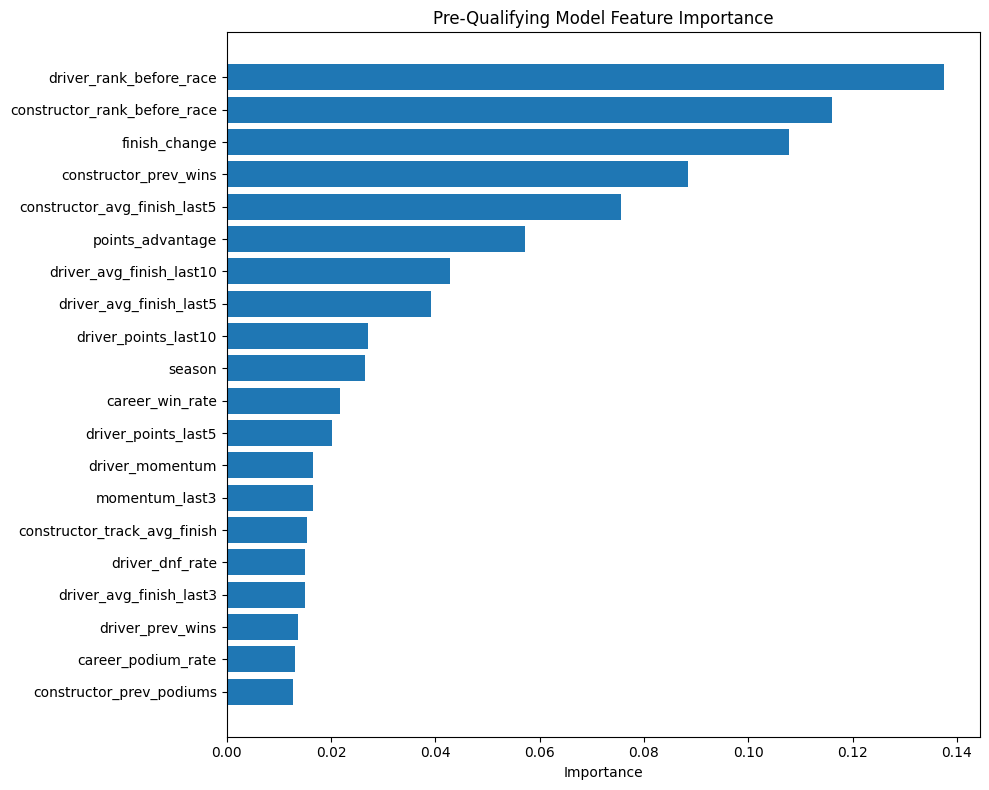

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

plot_df = pre_importance.head(top_n)

plt.figure(figsize=(10,8))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.title("Pre-Qualifying Model Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()

plt.show()

In [ ]:
import pickle

with open("f1_pre_quali_model.pkl", "wb") as f:
    pickle.dump(xgb_pre, f)

with open("f1_pre_quali_features.pkl", "wb") as f:
    pickle.dump(PRE_FEATURES, f)

In [ ]:
import pickle

pickle.dump(
    xgb_clean,
    open("f1_post_quali_model.pkl", "wb")
)

pickle.dump(
    FEATURES,
    open("f1_post_quali_features.pkl", "wb")
)

pickle.dump(
    xgb_pre,
    open("f1_pre_quali_model.pkl", "wb")
)

pickle.dump(
    PRE_FEATURES,
    open("f1_pre_quali_features.pkl", "wb")
)

#**RACE PREDICTION CODE**

In [ ]:
# Use Post-Qualifying Model first

master["win_probability"] = xgb_clean.predict_proba(
    master[FEATURES]
)[:,1]

master[[
    "race_id",
    "driver_id",
    "constructor_id",
    "win_probability"
]].head()

,race_id,driver_id,constructor_id,win_probability
0,2008_1,alonso,renault,0.000127
1,2008_1,barrichello,honda,0.000152
2,2008_1,bourdais,toro_rosso,0.000126
3,2008_1,button,honda,0.000075
4,2008_1,coulthard,red_bull,0.000295


In [ ]:
race = "2026_5"

In [ ]:
race_df = master[
    master["race_id"] == race
].copy()

race_df = race_df.sort_values(
    "win_probability",
    ascending=False
)

race_df[[
    "driver_id",
    "constructor_id",
    "win_probability"
]].head(10)

,driver_id,constructor_id,win_probability
7713,antonelli,mercedes,0.992274
7721,hamilton,ferrari,0.054885
7725,max_verstappen,red_bull,0.021923
7720,hadjar,red_bull,0.012111
7718,colapinto,alpine,0.002374
7724,leclerc,ferrari,0.000655
7719,gasly,alpine,0.000156
7726,norris,mclaren,0.000146
7730,russell,mercedes,0.000101
7723,lawson,rb,0.000078


In [ ]:
race_df["win_probability"] = (

    race_df["win_probability"]

    /

    race_df["win_probability"].sum()

)

In [ ]:
print(
    race_df["win_probability"].sum()
)

1.0


In [ ]:
def predict_race(
    race_id,
    df,
    model,
    features
):

    temp = df[
        df["race_id"] == race_id
    ].copy()

    temp["win_probability"] = (

        model.predict_proba(
            temp[features]
        )[:,1]

    )

    temp["win_probability"] = (

        temp["win_probability"]

        /

        temp["win_probability"].sum()

    )

    temp = temp.sort_values(
        "win_probability",
        ascending=False
    )

    return temp[
        [
            "driver_id",
            "constructor_id",
            "win_probability"
        ]
    ]

In [ ]:
predict_race(
    "2026_5",
    master,
    xgb_clean,
    FEATURES
).head(10)

,driver_id,constructor_id,win_probability
7713,antonelli,mercedes,0.914633
7721,hamilton,ferrari,0.050590
7725,max_verstappen,red_bull,0.020208
7720,hadjar,red_bull,0.011163
7718,colapinto,alpine,0.002188
7724,leclerc,ferrari,0.000604
7719,gasly,alpine,0.000144
7726,norris,mclaren,0.000134
7730,russell,mercedes,0.000093
7723,lawson,rb,0.000072


In [ ]:
pred = predict_race(
    "2026_5",
    master,
    xgb_clean,
    FEATURES
)

pred["predicted_position"] = range(
    1,
    len(pred)+1
)

pred.head(10)

,driver_id,constructor_id,win_probability,predicted_position
7713,antonelli,mercedes,0.914633,1
7721,hamilton,ferrari,0.050590,2
7725,max_verstappen,red_bull,0.020208,3
7720,hadjar,red_bull,0.011163,4
7718,colapinto,alpine,0.002188,5
7724,leclerc,ferrari,0.000604,6
7719,gasly,alpine,0.000144,7
7726,norris,mclaren,0.000134,8
7730,russell,mercedes,0.000093,9
7723,lawson,rb,0.000072,10


In [ ]:
POINTS = {

    1:25,
    2:18,
    3:15,
    4:12,
    5:10,

    6:8,
    7:6,
    8:4,
    9:2,
    10:1

}

In [ ]:
def simulate_race(
    race_id,
    df,
    model,
    features
):

    pred = predict_race(
        race_id,
        df,
        model,
        features
    )

    pred["predicted_position"] = range(
        1,
        len(pred)+1
    )

    pred["predicted_points"] = (

        pred["predicted_position"]

        .map(POINTS)

        .fillna(0)

    )

    return pred

In [ ]:
simulate_race(
    "2026_5",
    master,
    xgb_clean,
    FEATURES
).head(10)

,driver_id,constructor_id,win_probability,predicted_position,predicted_points
7713,antonelli,mercedes,0.914633,1,25.0
7721,hamilton,ferrari,0.050590,2,18.0
7725,max_verstappen,red_bull,0.020208,3,15.0
7720,hadjar,red_bull,0.011163,4,12.0
7718,colapinto,alpine,0.002188,5,10.0
7724,leclerc,ferrari,0.000604,6,8.0
7719,gasly,alpine,0.000144,7,6.0
7726,norris,mclaren,0.000134,8,4.0
7730,russell,mercedes,0.000093,9,2.0
7723,lawson,rb,0.000072,10,1.0


In [ ]:
season = 2026

season_races = (

    master[
        master["season"] == season
    ]

    ["race_id"]

    .unique()

)

In [ ]:
all_preds = []

for race in season_races:

    temp = simulate_race(
        race,
        master,
        xgb_clean,
        FEATURES
    )

    temp["race_id"] = race

    all_preds.append(temp)

season_results = pd.concat(
    all_preds,
    ignore_index=True
)

In [ ]:
driver_championship = (

    season_results

    .groupby(
        "driver_id"
    )

    ["predicted_points"]

    .sum()

    .reset_index()

    .sort_values(
        "predicted_points",
        ascending=False
    )

)

driver_championship.head(22)

,driver_id,predicted_points
2,antonelli,105.0
19,russell,57.0
14,max_verstappen,57.0
10,hamilton,50.0
13,leclerc,44.0
18,piastri,35.0
15,norris,30.0
9,hadjar,28.0
7,colapinto,20.0
8,gasly,14.0


In [ ]:
constructor_championship = (

    season_results

    .groupby(
        "constructor_id"
    )

    ["predicted_points"]

    .sum()

    .reset_index()

    .sort_values(
        "predicted_points",
        ascending=False
    )

)

constructor_championship.head(11)

,constructor_id,predicted_points
7,mercedes,162.0
4,ferrari,94.0
9,red_bull,85.0
6,mclaren,65.0
0,alpine,34.0
10,williams,18.0
5,haas,15.0
3,cadillac,14.0
8,rb,10.0
2,audi,8.0


In [ ]:
driver_championship.head(10)

constructor_championship.head(10)

,constructor_id,predicted_points
7,mercedes,162.0
4,ferrari,94.0
9,red_bull,85.0
6,mclaren,65.0
0,alpine,34.0
10,williams,18.0
5,haas,15.0
3,cadillac,14.0
8,rb,10.0
2,audi,8.0


In [ ]:
master[
    master["season"] == 2026
]["race_id"].nunique()

5

In [ ]:
master[
    master["season"] == 2026
][["race_id","round"]].drop_duplicates().tail(30)

,race_id,round
7623,2026_1,1
7645,2026_2,2
7667,2026_3,3
7689,2026_4,4
7711,2026_5,5


In [ ]:
predict_race(
    "2026_6",
    master,
    xgb_clean,
    FEATURES
)

,driver_id,constructor_id,win_probability


In [ ]:
master["position_order"].describe()

,position_order
count,7733.000000
mean,11.034010
std,6.143651
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,24.000000


In [ ]:
master["position_order"].value_counts().sort_index()

,count
position_order,
1,369
2,369
3,369
4,369
5,369
6,369
7,369
8,369
9,369


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
POSITION_FEATURES = [

    col for col in PRE_FEATURES

    if col in master.columns
]

In [ ]:
print(len(POSITION_FEATURES))
print(POSITION_FEATURES[:10])

33
['season', 'round', 'driver_avg_finish_last3', 'driver_avg_finish_last5', 'driver_avg_finish_last10', 'driver_prev_wins', 'driver_prev_podiums', 'driver_dnf_rate', 'constructor_avg_finish_last5', 'constructor_prev_wins']


In [ ]:
master = master.sort_values(
    ["season","round"]
)

split_index = int(
    len(master) * 0.8
)

train = master.iloc[:split_index]
test = master.iloc[split_index:]

In [ ]:
X_train = train[POSITION_FEATURES]
y_train = train["position_order"]

X_test = test[POSITION_FEATURES]
y_test = test["position_order"]

In [ ]:
position_model = XGBRegressor(

    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

In [ ]:
position_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = position_model.predict(
    X_test
)

In [ ]:
mae = mean_absolute_error(
    y_test,
    pred
)

r2 = r2_score(
    y_test,
    pred
)

print("MAE:", mae)
print("R2 :", r2)

MAE: 1.1312562227249146
R2 : 0.9315221905708313


In [ ]:
importance_df = pd.DataFrame({

    "feature": POSITION_FEATURES,

    "importance":
    position_model.feature_importances_

})

importance_df = (

    importance_df

    .sort_values(
        "importance",
        ascending=False
    )

)

importance_df.head(30)

,feature,importance
11,finish_change,0.224044
4,driver_avg_finish_last10,0.219578
31,constructor_points_last5,0.093928
8,constructor_avg_finish_last5,0.052750
29,driver_points_last5,0.044785
12,momentum_last3,0.041185
3,driver_avg_finish_last5,0.032178
26,driver_rank_before_race,0.031529
30,driver_points_last10,0.028924
2,driver_avg_finish_last3,0.028332


In [ ]:
import pickle

pickle.dump(
    position_model,
    open(
        "f1_position_model.pkl",
        "wb"
    )
)

In [ ]:
import pickle

pickle.dump(
    position_model,
    open("f1_position_model.pkl", "wb")
)

pickle.dump(
    POSITION_FEATURES,
    open("f1_position_features.pkl", "wb")
)

In [ ]:
def predict_race_order(
    race_id,
    df,
    model,
    features
):

    race_df = df[
        df["race_id"] == race_id
    ].copy()

    race_df["predicted_position"] = model.predict(
        race_df[features]
    )

    race_df = race_df.sort_values(
        "predicted_position"
    )

    race_df["predicted_rank"] = range(
        1,
        len(race_df)+1
    )

    return race_df[
        [
            "predicted_rank",
            "driver_id",
            "constructor_id",
            "predicted_position"
        ]
    ]

In [ ]:
race_prediction = predict_race_order(
    "2026_5",
    master,
    position_model,
    POSITION_FEATURES
)

race_prediction.head(20)

,predicted_rank,driver_id,constructor_id,predicted_position
7713,1,antonelli,mercedes,2.094403
7725,2,max_verstappen,red_bull,2.461033
7721,3,hamilton,ferrari,3.166162
7724,4,leclerc,ferrari,3.283758
7720,5,hadjar,red_bull,6.689172
7723,6,lawson,rb,7.021585
7719,7,gasly,alpine,8.280364
7718,8,colapinto,alpine,8.485461
7729,9,piastri,mclaren,10.495707
7731,10,sainz,williams,11.020435


In [ ]:
POINTS = {

    1:25,
    2:18,
    3:15,
    4:12,
    5:10,

    6:8,
    7:6,
    8:4,
    9:2,
    10:1

}

In [ ]:
def assign_points(df):

    df = df.copy()

    df["predicted_points"] = (

        df["predicted_rank"]

        .map(POINTS)

        .fillna(0)

    )

    return df

In [ ]:
race_prediction = assign_points(
    race_prediction
)

race_prediction.head(10)

,predicted_rank,driver_id,constructor_id,predicted_position,predicted_points
7713,1,antonelli,mercedes,2.094403,25.0
7725,2,max_verstappen,red_bull,2.461033,18.0
7721,3,hamilton,ferrari,3.166162,15.0
7724,4,leclerc,ferrari,3.283758,12.0
7720,5,hadjar,red_bull,6.689172,10.0
7723,6,lawson,rb,7.021585,8.0
7719,7,gasly,alpine,8.280364,6.0
7718,8,colapinto,alpine,8.485461,4.0
7729,9,piastri,mclaren,10.495707,2.0
7731,10,sainz,williams,11.020435,1.0


In [ ]:
SEASON = 2026

all_races = sorted(

    master[
        master["season"] == SEASON
    ]["race_id"].unique()

)

In [ ]:
season_predictions = []

for race in all_races:

    temp = predict_race_order(
        race,
        master,
        position_model,
        POSITION_FEATURES
    )

    temp = assign_points(temp)

    temp["race_id"] = race

    season_predictions.append(temp)

season_predictions = pd.concat(
    season_predictions,
    ignore_index=True
)

In [ ]:
season_predictions.head(20)

,predicted_rank,driver_id,constructor_id,predicted_position,predicted_points,race_id
0,1,russell,mercedes,1.420408,25.0,2026_1
1,2,leclerc,ferrari,3.940012,18.0,2026_1
2,3,antonelli,mercedes,4.376094,15.0,2026_1
3,4,norris,mclaren,5.625638,12.0,2026_1
4,5,hamilton,ferrari,5.719815,10.0,2026_1
5,6,bearman,haas,8.497732,8.0,2026_1
6,7,max_verstappen,red_bull,8.521998,6.0,2026_1
7,8,bortoleto,audi,8.829202,4.0,2026_1
8,9,gasly,alpine,10.102168,2.0,2026_1
9,10,ocon,haas,10.648335,1.0,2026_1


In [ ]:
driver_standings = (
    season_predictions
    .groupby("driver_id")["predicted_points"]
    .sum()
    .reset_index()
    .sort_values(
        "predicted_points",
        ascending=False
    )
)

driver_standings.head(20)

,driver_id,predicted_points
2,antonelli,115.0
19,russell,73.0
13,leclerc,68.0
10,hamilton,58.0
15,norris,37.0
14,max_verstappen,32.0
18,piastri,29.0
4,bearman,19.0
8,gasly,18.0
12,lawson,17.0


In [ ]:
constructor_standings = (
    season_predictions
    .groupby("constructor_id")["predicted_points"]
    .sum()
    .reset_index()
    .sort_values(
        "predicted_points",
        ascending=False
    )
)

constructor_standings.head(10)

,constructor_id,predicted_points
7,mercedes,188.0
4,ferrari,126.0
6,mclaren,66.0
9,red_bull,48.0
0,alpine,28.0
5,haas,22.0
8,rb,17.0
2,audi,6.0
10,williams,4.0
1,aston_martin,0.0


In [ ]:
eval_df = master.copy()

eval_df["predicted_position"] = position_model.predict(
    eval_df[POSITION_FEATURES]
)

eval_df["position_error"] = (

    eval_df["position_order"]

    -

    eval_df["predicted_position"]

).abs()

In [ ]:
print(
    eval_df["position_error"].mean()
)

0.5629501584914898


In [ ]:
winner_hits = 0
total_races = 0

for race in master["race_id"].unique():

    race_actual = master[
        master["race_id"] == race
    ]

    actual_winner = (

        race_actual

        .sort_values(
            "position_order"
        )

        .iloc[0]["driver_id"]
    )

    pred = predict_race_order(
        race,
        master,
        position_model,
        POSITION_FEATURES
    )

    predicted_winner = pred.iloc[0]["driver_id"]

    if actual_winner == predicted_winner:

        winner_hits += 1

    total_races += 1

print(
    "Winner Accuracy:",
    winner_hits / total_races
)

Winner Accuracy: 0.9214092140921409


In [ ]:
master[
    master["season"] == 2026
][
[
    "race_id",
    "round"
]
].drop_duplicates()

,race_id,round
7623,2026_1,1
7645,2026_2,2
7667,2026_3,3
7689,2026_4,4
7711,2026_5,5


In [ ]:
master[
    master["race_id"] == "2026_5"
][
[
    "driver_id",
    "constructor_id"
]
].sort_values(
    "constructor_id"
)

,driver_id,constructor_id
7718,colapinto,alpine
7719,gasly,alpine
7732,stroll,aston_martin
7712,alonso,aston_martin
7722,hulkenberg,audi
7716,bortoleto,audi
7728,perez,cadillac
7717,bottas,cadillac
7724,leclerc,ferrari
7721,hamilton,ferrari


In [ ]:
current_grid = master[
    master["race_id"] == "2026_5"
][
    ["driver_id", "constructor_id"]
].copy()

In [ ]:
latest_state = (
    master
    .sort_values(["season", "round"])
    .groupby("driver_id")
    .tail(1)
)

latest_state = latest_state.merge(
    current_grid,
    on=["driver_id", "constructor_id"],
    how="inner"
)

In [ ]:
print(len(latest_state))

latest_state[
[
    "driver_id",
    "constructor_id",
    "driver_points_before_race",
    "driver_rank_before_race",
    "constructor_rank_before_race"
]
].sort_values(
    "driver_points_before_race",
    ascending=False
)

22


,driver_id,constructor_id,driver_points_before_race,driver_rank_before_race,constructor_rank_before_race
2,antonelli,mercedes,93.0,1.0,2.0
19,russell,mercedes,67.0,2.0,1.0
13,leclerc,ferrari,50.0,3.0,3.0
10,hamilton,ferrari,41.0,4.0,4.0
15,norris,mclaren,38.0,5.0,5.0
18,piastri,mclaren,33.0,6.0,5.0
14,max_verstappen,red_bull,22.0,7.0,6.0
4,bearman,haas,16.0,8.0,11.0
8,gasly,alpine,15.0,9.0,7.0
12,lawson,rb,8.0,10.0,12.0


In [ ]:
races[
    races["year"] == 2026
][
    ["round", "name", "circuitId"]
].sort_values("round")

,round,name,circuitId
1149,1,Australian Grand Prix,1
1150,2,Chinese Grand Prix,17
1151,3,Japanese Grand Prix,22
1152,4,Miami Grand Prix,79
1153,5,Canadian Grand Prix,7
1154,6,Monaco Grand Prix,6
1155,7,Barcelona Grand Prix,4
1156,8,Austrian Grand Prix,70
1157,9,British Grand Prix,9
1158,10,Belgian Grand Prix,13


In [ ]:
FIA_POINTS = {
    1: 25,
    2: 18,
    3: 15,
    4: 12,
    5: 10,
    6: 8,
    7: 6,
    8: 4,
    9: 2,
    10: 1
}

def assign_fia_points(df):

    df = df.copy()

    df["predicted_points"] = (
        df["predicted_position"]
        .map(FIA_POINTS)
        .fillna(0)
    )

    return df

In [ ]:
future_races = races[
    (races["year"] == 2026) &
    (races["round"] >= 6)
][
    ["round", "name", "circuitId"]
].sort_values("round")

future_races

,round,name,circuitId
1154,6,Monaco Grand Prix,6
1155,7,Barcelona Grand Prix,4
1156,8,Austrian Grand Prix,70
1157,9,British Grand Prix,9
1158,10,Belgian Grand Prix,13
1159,11,Hungarian Grand Prix,11
1160,12,Dutch Grand Prix,39
1161,13,Italian Grand Prix,14
1162,14,Spanish Grand Prix,81
1163,15,Azerbaijan Grand Prix,73


In [ ]:
current_state = latest_state.copy()

In [ ]:
current_state.head()

,race_id,driver_id,constructor_id,grid,position_order,points,laps,status,qualifying_position,q1,q2,q3,winner,podium,dnf,q1_sec,q2_sec,q3_sec,best_quali_time,season,round,driver_avg_finish_last3,driver_avg_finish_last5,driver_avg_finish_last10,driver_prev_wins,driver_prev_podiums,driver_dnf_rate,constructor_avg_finish_last5,constructor_prev_wins,constructor_prev_podiums,finish_change,momentum_last3,avg_quali_last5,quali_change,name,circuitId,name_circuit,country,driver_track_avg_finish,driver_track_wins,driver_track_podiums,driver_track_dnf_rate,constructor_track_avg_finish,constructor_track_wins,constructor_track_dnf_rate,driver_prev_races,career_win_rate,career_podium_rate,driver_momentum,driver_points_before_race,driver_rank_before_race,constructor_points_before_race,constructor_rank_before_race,driver_points_last5,driver_points_last10,constructor_points_last5,grid_gain,avg_quali_last3,previous_poles,top10,quali_advantage,grid_advantage,points_advantage,win_probability
0,2026_5,albon,williams,18.0,21,0.0,11,Collision,18.0,1:14.851,\N,\N,0,0,1,74.851,87.456,87.1785,74.851,2026,5,17.333333,16.0,14.4,0.0,2.0,0.436090,16.0,0.0,0.0,11.0,-0.666667,16.4,3.0,Canadian Grand Prix,7,Circuit Gilles Villeneuve,Canada,15.200000,0.0,0.0,0.600000,13.766667,0.0,0.666667,133,0.000000,0.015038,-4.000000e-01,1.0,14.0,5.0,13.0,1.0,1.0,5.0,0.0,16.666667,0,0,-6.5,-6.5,-17.363636,0.000003
1,2026_5,alonso,aston_martin,19.0,20,0.0,23,Seat,19.0,1:15.196,\N,\N,0,0,1,75.196,87.456,87.1785,75.196,2026,5,16.666667,14.8,13.4,13.0,57.0,0.366972,14.8,0.0,8.0,5.0,-1.000000,16.0,2.0,Canadian Grand Prix,7,Circuit Gilles Villeneuve,Canada,10.214286,0.0,3.0,0.428571,8.750000,0.0,0.125000,327,0.039755,0.174312,1.800000e+00,0.0,15.0,0.0,15.0,8.0,15.0,0.0,0.0,19.000000,5,0,-7.5,-7.5,-18.363636,0.000004
2,2026_5,antonelli,mercedes,2.0,1,25.0,68,Finished,2.0,1:13.380,1:13.076,1:12.646,1,1,0,73.380,73.076,72.6460,72.646,2026,5,1.000000,4.0,4.9,3.0,7.0,0.214286,4.0,3.0,7.0,0.0,-0.333333,3.8,1.0,Canadian Grand Prix,7,Circuit Gilles Villeneuve,Canada,3.000000,0.0,1.0,0.000000,5.392857,5.0,0.142857,28,0.107143,0.250000,-2.900000e+00,93.0,1.0,160.0,2.0,93.0,144.0,92.0,0.0,1.000000,3,1,9.5,9.5,74.636364,0.992274
3,2026_5,arvid_lindblad,rb,9.0,22,0.0,0,Gearbox,9.0,1:13.895,1:13.548,1:13.280,0,0,1,73.895,73.548,73.2800,73.280,2026,5,13.333333,12.0,12.0,0.0,0.0,0.750000,12.0,0.0,0.0,8.0,2.000000,12.5,-7.0,Canadian Grand Prix,7,Circuit Gilles Villeneuve,Canada,10.207143,0.0,0.0,0.400000,14.250000,0.0,0.500000,4,0.000000,0.000000,-7.557077e-16,4.0,12.0,12.0,12.0,4.0,4.0,8.0,0.0,13.666667,0,0,2.5,2.5,-14.363636,0.000002
4,2026_5,bearman,haas,16.0,10,1.0,67,+1 Lap,16.0,1:14.449,1:14.416,\N,0,0,1,74.449,74.416,87.1785,74.416,2026,5,12.666667,11.4,10.5,0.0,0.0,0.290323,11.4,0.0,0.0,-1.0,1.333333,12.6,4.0,Canadian Grand Prix,7,Circuit Gilles Villeneuve,Canada,11.000000,0.0,0.0,1.000000,13.500000,0.0,0.812500,31,0.000000,0.000000,1.300000e+00,16.0,8.0,17.0,11.0,16.0,39.0,1.0,0.0,13.333333,0,1,-4.5,-4.5,-2.363636,0.000011


In [ ]:
monaco_circuit = 6

In [ ]:
monaco_features = current_state.copy()

monaco_features["season"] = 2026
monaco_features["round"] = 6
monaco_features["circuitId"] = monaco_circuit

In [ ]:
track_history = (

    master[
        master["circuitId"] == monaco_circuit
    ]

    .groupby("driver_id")

    .agg({
        "position_order":"mean",
        "winner":"sum",
        "podium":"sum"
    })

    .reset_index()

)

In [ ]:
track_history.columns = [

    "driver_id",

    "driver_track_avg_finish",

    "driver_track_wins",

    "driver_track_podiums"

]

In [ ]:
monaco_features = monaco_features.merge(
    track_history,
    on="driver_id",
    how="left",
    suffixes=("", "_new")
)

In [ ]:
X_monaco = monaco_features[
    POSITION_FEATURES
].fillna(0)

In [ ]:
X_monaco = monaco_features[
    POSITION_FEATURES
].fillna(0)

In [ ]:
monaco_features["predicted_position"] = (
    position_model.predict(X_monaco)
)

In [ ]:
monaco_features = monaco_features.sort_values(
    "predicted_position"
)

monaco_features["predicted_position"] = range(
    1,
    len(monaco_features)+1
)

In [ ]:
monaco_features[
[
    "driver_id",
    "constructor_id",
    "predicted_position"
]
].head(10)

,driver_id,constructor_id,predicted_position
2,antonelli,mercedes,1
14,max_verstappen,red_bull,2
10,hamilton,ferrari,3
13,leclerc,ferrari,4
9,hadjar,red_bull,5
12,lawson,rb,6
8,gasly,alpine,7
7,colapinto,alpine,8
18,piastri,mclaren,9
20,sainz,williams,10


In [ ]:
monaco_features["predicted_score"] = (
    position_model.predict(X_monaco)
)

monaco_features[
[
    "driver_id",
    "constructor_id",
    "predicted_score"
]
].sort_values(
    "predicted_score"
).head(15)

,driver_id,constructor_id,predicted_score
10,hamilton,ferrari,2.086112
6,bottas,cadillac,2.472395
11,hulkenberg,audi,3.153611
5,bortoleto,audi,3.295120
20,sainz,williams,6.570764
4,bearman,haas,7.019732
18,piastri,mclaren,8.291724
7,colapinto,alpine,8.490773
19,russell,mercedes,10.510248
3,arvid_lindblad,rb,11.021905


In [ ]:
monaco_features[
[
    "driver_id",
    "driver_rank_before_race",
    "driver_points_before_race",
    "driver_avg_finish_last5",
    "driver_track_wins",
    "career_win_rate"
]
].sort_values(
    "driver_rank_before_race"
)

,driver_id,driver_rank_before_race,driver_points_before_race,driver_avg_finish_last5,driver_track_wins,career_win_rate
2,antonelli,1.0,93.0,4.0,0.0,0.107143
19,russell,2.0,67.0,3.2,1.0,0.038462
13,leclerc,3.0,50.0,4.0,0.0,0.045198
10,hamilton,4.0,41.0,5.6,6.0,0.275204
15,norris,5.0,38.0,7.0,0.0,0.070513
18,piastri,6.0,33.0,9.4,0.0,0.121622
14,max_verstappen,7.0,22.0,7.2,3.0,0.299578
4,bearman,8.0,16.0,11.4,0.0,0.000000
8,gasly,9.0,15.0,12.6,0.0,0.005495
12,lawson,10.0,8.0,13.4,0.0,0.000000


In [ ]:
monaco_history = master[
    master["circuitId"] == 6
]

print(monaco_history.shape)

monaco_history[
[
    "driver_id",
    "position_order",
    "winner",
    "podium"
]
].head()

(358, 64)


,driver_id,position_order,winner,podium
108,alonso,10,0,0
109,barrichello,6,0,0
110,bourdais,20,0,0
111,button,11,0,0
112,coulthard,19,0,0


In [ ]:
monaco_driver_stats = (
    master[
        master["circuitId"] == 6
    ]
    .groupby("driver_id")
    .agg(
        track_avg_finish=("position_order","mean"),
        track_wins=("winner","sum"),
        track_podiums=("podium","sum")
    )
    .reset_index()
)

monaco_driver_stats.sort_values(
    "track_wins",
    ascending=False
).head(20)

,driver_id,track_avg_finish,track_wins,track_podiums
29,hamilton,4.764706,3,6
65,rosberg,5.777778,3,4
78,webber,3.000000,2,3
47,max_verstappen,6.900000,2,3
77,vettel,5.571429,2,7
63,ricciardo,8.636364,1,4
43,leclerc,10.142857,1,2
56,perez,12.153846,1,2
54,norris,5.666667,1,2
13,button,10.100000,1,2


In [ ]:
print("predict_race_order" in globals())

True


In [ ]:
import inspect

print(inspect.getsource(predict_race_order))

def predict_race_order(
    race_id,
    df,
    model,
    features
):

    race_df = df[
        df["race_id"] == race_id
    ].copy()

    race_df["predicted_position"] = model.predict(
        race_df[features]
    )

    race_df = race_df.sort_values(
        "predicted_position"
    )

    race_df["predicted_rank"] = range(
        1,
        len(race_df)+1
    )

    return race_df[
        [
            "predicted_rank",
            "driver_id",
            "constructor_id",
            "predicted_position"
        ]
    ]



In [ ]:
for col in master.columns:
    if "points_before" in col or "rank_before" in col:
        print(col)

driver_points_before_race
driver_rank_before_race
constructor_points_before_race
constructor_rank_before_race


In [ ]:
master[
    [
        "race_id",
        "driver_id",
        "driver_points_before_race",
        "driver_rank_before_race",
        "constructor_points_before_race",
        "constructor_rank_before_race"
    ]
].tail(30)

,race_id,driver_id,driver_points_before_race,driver_rank_before_race,constructor_points_before_race,constructor_rank_before_race
7703,2026_4,max_verstappen,12.0,9.0,16.0,9.0
7704,2026_4,norris,20.0,5.0,38.0,6.0
7705,2026_4,ocon,1.0,13.0,17.0,8.0
7706,2026_4,perez,0.0,14.0,0.0,13.0
7707,2026_4,piastri,18.0,6.0,56.0,5.0
7708,2026_4,russell,55.0,2.0,148.0,1.0
7709,2026_4,sainz,2.0,12.0,3.0,11.0
7710,2026_4,stroll,0.0,14.0,0.0,13.0
7711,2026_5,albon,1.0,14.0,5.0,13.0
7712,2026_5,alonso,0.0,15.0,0.0,15.0


In [ ]:
master[
    master["driver_id"] == "hamilton"
][
    [
        "race_id",
        "points",
        "driver_points_before_race",
        "driver_rank_before_race"
    ]
].tail(15)

,race_id,points,driver_points_before_race,driver_rank_before_race
7431,2025_15,0.0,95.0,6.0
7451,2025_16,8.0,95.0,6.0
7471,2025_17,4.0,103.0,6.0
7491,2025_18,4.0,107.0,6.0
7511,2025_19,12.0,111.0,6.0
7531,2025_20,4.0,123.0,6.0
7551,2025_21,0.0,127.0,6.0
7571,2025_22,4.0,127.0,6.0
7591,2025_23,0.0,131.0,6.0
7611,2025_24,4.0,131.0,7.0


In [ ]:
latest_2026 = (
    master[master["season"] == 2026]
    .sort_values(["round", "driver_rank_before_race"])
)

latest_2026[
    [
        "driver_id",
        "constructor_id",
        "driver_points_before_race",
        "driver_rank_before_race",
        "constructor_rank_before_race"
    ]
].head(25)

,driver_id,constructor_id,driver_points_before_race,driver_rank_before_race,constructor_rank_before_race
7623,albon,williams,18.0,10.0,9.0
7624,alonso,aston_martin,18.0,10.0,9.0
7625,antonelli,mercedes,18.0,10.0,9.0
7626,arvid_lindblad,rb,18.0,10.0,9.0
7627,bearman,haas,18.0,10.0,9.0
7628,bortoleto,audi,18.0,10.0,9.0
7629,bottas,cadillac,18.0,10.0,9.0
7630,colapinto,alpine,18.0,10.0,9.0
7631,gasly,alpine,18.0,10.0,7.0
7632,hadjar,red_bull,18.0,10.0,9.0


In [ ]:
print(len(POSITION_FEATURES))
print(POSITION_FEATURES)

33
['season', 'round', 'driver_avg_finish_last3', 'driver_avg_finish_last5', 'driver_avg_finish_last10', 'driver_prev_wins', 'driver_prev_podiums', 'driver_dnf_rate', 'constructor_avg_finish_last5', 'constructor_prev_wins', 'constructor_prev_podiums', 'finish_change', 'momentum_last3', 'circuitId', 'driver_track_avg_finish', 'driver_track_wins', 'driver_track_podiums', 'driver_track_dnf_rate', 'constructor_track_avg_finish', 'constructor_track_wins', 'constructor_track_dnf_rate', 'driver_prev_races', 'career_win_rate', 'career_podium_rate', 'driver_momentum', 'driver_points_before_race', 'driver_rank_before_race', 'constructor_points_before_race', 'constructor_rank_before_race', 'driver_points_last5', 'driver_points_last10', 'constructor_points_last5', 'points_advantage']


In [ ]:
print(type(position_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [ ]:
print(type(position_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [ ]:
print(len(POSITION_FEATURES))

33


In [ ]:
POSITION_FEATURES

['season',
 'round',
 'driver_avg_finish_last3',
 'driver_avg_finish_last5',
 'driver_avg_finish_last10',
 'driver_prev_wins',
 'driver_prev_podiums',
 'driver_dnf_rate',
 'constructor_avg_finish_last5',
 'constructor_prev_wins',
 'constructor_prev_podiums',
 'finish_change',
 'momentum_last3',
 'circuitId',
 'driver_track_avg_finish',
 'driver_track_wins',
 'driver_track_podiums',
 'driver_track_dnf_rate',
 'constructor_track_avg_finish',
 'constructor_track_wins',
 'constructor_track_dnf_rate',
 'driver_prev_races',
 'career_win_rate',
 'career_podium_rate',
 'driver_momentum',
 'driver_points_before_race',
 'driver_rank_before_race',
 'constructor_points_before_race',
 'constructor_rank_before_race',
 'driver_points_last5',
 'driver_points_last10',
 'constructor_points_last5',
 'points_advantage']

In [ ]:
sim_master = master.copy()

In [ ]:
POINTS_TABLE = {
    1: 25,
    2: 18,
    3: 15,
    4: 12,
    5: 10,
    6: 8,
    7: 6,
    8: 4,
    9: 2,
    10: 1
}

In [ ]:
def assign_points(position):

    return POINTS_TABLE.get(position, 0)

In [ ]:
def build_current_standings(df):

    driver_standings = (
        df.groupby("driver_id")["sim_points"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    driver_standings["rank"] = (
        driver_standings["sim_points"]
        .rank(method="min", ascending=False)
    )

    constructor_standings = (
        df.groupby("constructor_id")["sim_points"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    constructor_standings["rank"] = (
        constructor_standings["sim_points"]
        .rank(method="min", ascending=False)
    )

    return driver_standings, constructor_standings

In [ ]:
sim_master["sim_points"] = sim_master["points"]

In [ ]:
drivers, constructors = build_current_standings(
    sim_master[
        sim_master["season"] == 2026
    ]
)

print(drivers.head(10))
print()
print(constructors.head(10))

        driver_id  sim_points  rank
0       antonelli       118.0   1.0
1         russell        67.0   2.0
2         leclerc        62.0   3.0
3        hamilton        59.0   4.0
4          norris        38.0   5.0
5  max_verstappen        37.0   6.0
6         piastri        33.0   7.0
7           gasly        19.0   8.0
8         bearman        17.0   9.0
9          hadjar        14.0  10.0

  constructor_id  sim_points  rank
0       mercedes       185.0   1.0
1        ferrari       121.0   2.0
2        mclaren        71.0   3.0
3       red_bull        51.0   4.0
4         alpine        32.0   5.0
5             rb        18.0   6.0
6           haas        18.0   6.0
7       williams         7.0   8.0
8           audi         2.0   9.0
9   aston_martin         0.0  10.0


In [ ]:
future_races = races[
    (races["year"] == 2026) &
    (races["round"] >= 6)
][
    ["round","name","circuitId"]
]

future_races

,round,name,circuitId
1154,6,Monaco Grand Prix,6
1155,7,Barcelona Grand Prix,4
1156,8,Austrian Grand Prix,70
1157,9,British Grand Prix,9
1158,10,Belgian Grand Prix,13
1159,11,Hungarian Grand Prix,11
1160,12,Dutch Grand Prix,39
1161,13,Italian Grand Prix,14
1162,14,Spanish Grand Prix,81
1163,15,Azerbaijan Grand Prix,73


In [ ]:
future_races = races[
    (races["year"] == 2026) &
    (races["round"] >= 6)
].copy()

future_races = future_races[
    ["round", "name", "circuitId"]
]

future_races

,round,name,circuitId
1154,6,Monaco Grand Prix,6
1155,7,Barcelona Grand Prix,4
1156,8,Austrian Grand Prix,70
1157,9,British Grand Prix,9
1158,10,Belgian Grand Prix,13
1159,11,Hungarian Grand Prix,11
1160,12,Dutch Grand Prix,39
1161,13,Italian Grand Prix,14
1162,14,Spanish Grand Prix,81
1163,15,Azerbaijan Grand Prix,73


In [ ]:
latest_grid = (
    master[
        master["race_id"] == "2026_5"
    ]
    .copy()
)

latest_grid = latest_grid.sort_values(
    "driver_rank_before_race"
)

latest_grid[
    [
        "driver_id",
        "constructor_id"
    ]
]

,driver_id,constructor_id
7713,antonelli,mercedes
7730,russell,mercedes
7724,leclerc,ferrari
7721,hamilton,ferrari
7726,norris,mclaren
7729,piastri,mclaren
7725,max_verstappen,red_bull
7715,bearman,haas
7719,gasly,alpine
7723,lawson,rb


In [ ]:
def create_future_race_grid(
    base_grid,
    circuit_id,
    round_num
):

    race_df = base_grid.copy()

    race_df["season"] = 2026
    race_df["round"] = round_num
    race_df["circuitId"] = circuit_id

    return race_df

In [ ]:
def predict_future_race(
    race_df,
    model,
    features
):

    X = race_df[features].fillna(0)

    race_df["predicted_position"] = model.predict(X)

    race_df = race_df.sort_values(
        "predicted_position"
    )

    race_df["predicted_rank"] = range(
        1,
        len(race_df)+1
    )

    race_df["sim_points"] = (
        race_df["predicted_rank"]
        .apply(assign_points)
    )

    return race_df

In [ ]:
season_results = []

working_grid = latest_grid.copy()

for _, race in future_races.iterrows():

    race_df = create_future_race_grid(
        working_grid,
        race["circuitId"],
        race["round"]
    )

    prediction = predict_future_race(
        race_df,
        position_model,
        POSITION_FEATURES
    )

    prediction["race_name"] = race["name"]

    season_results.append(
        prediction
    )

season_results = pd.concat(
    season_results,
    ignore_index=True
)

In [ ]:
predicted_winners = (
    season_results[
        season_results["predicted_rank"] == 1
    ]
    [
        [
            "race_name",
            "driver_id",
            "constructor_id"
        ]
    ]
)

predicted_winners

,race_name,driver_id,constructor_id
0,Monaco Grand Prix,antonelli,mercedes
22,Barcelona Grand Prix,antonelli,mercedes
44,Austrian Grand Prix,antonelli,mercedes
66,British Grand Prix,antonelli,mercedes
88,Belgian Grand Prix,antonelli,mercedes
110,Hungarian Grand Prix,antonelli,mercedes
132,Dutch Grand Prix,antonelli,mercedes
154,Italian Grand Prix,antonelli,mercedes
176,Spanish Grand Prix,antonelli,mercedes
198,Azerbaijan Grand Prix,antonelli,mercedes


In [ ]:
future_driver_points = (
    season_results
    .groupby("driver_id")["sim_points"]
    .sum()
)

current_driver_points = (
    master[
        master["season"] == 2027
    ]
    .groupby("driver_id")["points"]
    .sum()
)

driver_championship = (
    current_driver_points
    .add(
        future_driver_points,
        fill_value=0
    )
    .sort_values(
        ascending=False
    )
    .reset_index()
)

driver_championship.columns = [
    "driver_id",
    "projected_points"
]

driver_championship.head(20)

,driver_id,projected_points
0,antonelli,411.0
1,max_verstappen,320.0
2,leclerc,234.0
3,hamilton,225.0
4,hadjar,170.0
5,lawson,136.0
6,colapinto,86.0
7,gasly,84.0
8,piastri,34.0
9,sainz,13.0


In [ ]:
future_constructor_points = (
    season_results
    .groupby("constructor_id")["sim_points"]
    .sum()
)

current_constructor_points = (
    master[
        master["season"] == 2027
    ]
    .groupby("constructor_id")["points"]
    .sum()
)

constructor_championship = (
    current_constructor_points
    .add(
        future_constructor_points,
        fill_value=0
    )
    .sort_values(
        ascending=False
    )
    .reset_index()
)

constructor_championship.columns = [
    "constructor_id",
    "projected_points"
]

constructor_championship.head(10)

,constructor_id,projected_points
0,red_bull,490.0
1,ferrari,459.0
2,mercedes,411.0
3,alpine,170.0
4,rb,136.0
5,mclaren,34.0
6,williams,13.0
7,audi,4.0
8,aston_martin,0.0
9,haas,0.0


In [ ]:
import pickle

with open(
    "f1_position_model.pkl",
    "wb"
) as f:
    pickle.dump(
        position_model,
        f
    )

with open(
    "f1_position_features.pkl",
    "wb"
) as f:
    pickle.dump(
        POSITION_FEATURES,
        f
    )

In [ ]:
train = master[master["season"] < 2025]

test = master[master["season"] == 2025]


In [ ]:
position_model.fit(
    train[POSITION_FEATURES],
    train["position_order"]
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
test["predicted_position"] = position_model.predict(
    test[POSITION_FEATURES]
)

/tmp/ipykernel_1923/390502721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["predicted_position"] = position_model.predict(


In [ ]:
race_prediction.sort_values(
    "predicted_position"
)

,predicted_rank,driver_id,constructor_id,predicted_position,predicted_points
7713,1,antonelli,mercedes,2.094403,25.0
7725,2,max_verstappen,red_bull,2.461033,18.0
7721,3,hamilton,ferrari,3.166162,15.0
7724,4,leclerc,ferrari,3.283758,12.0
7720,5,hadjar,red_bull,6.689172,10.0
7723,6,lawson,rb,7.021585,8.0
7719,7,gasly,alpine,8.280364,6.0
7718,8,colapinto,alpine,8.485461,4.0
7729,9,piastri,mclaren,10.495707,2.0
7731,10,sainz,williams,11.020435,1.0


In [ ]:
train_df = master[
    (master["season"] >= 2011) &
    (master["season"] <= 2024)
].copy()

test_2025 = master[
    master["season"] == 2025
].copy()

In [ ]:
from xgboost import XGBRegressor

backtest_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

backtest_model.fit(
    train_df[POSITION_FEATURES].fillna(0),
    train_df["position_order"]
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_absolute_error

pred = backtest_model.predict(
    test_2025[POSITION_FEATURES].fillna(0)
)

print(
    "MAE:",
    mean_absolute_error(
        test_2025["position_order"],
        pred
    )
)

MAE: 1.1493663787841797


In [ ]:
test_2025["predicted_position"] = (
    backtest_model.predict(
        test_2025[POSITION_FEATURES].fillna(0)
    )
)

In [ ]:
race_predictions = []

for race_id in sorted(
    test_2025["race_id"].unique()
):

    race_df = test_2025[
        test_2025["race_id"] == race_id
    ].copy()

    race_df = race_df.sort_values(
        "predicted_position"
    )

    race_df["predicted_rank"] = range(
        1,
        len(race_df)+1
    )

    race_predictions.append(race_df)

race_predictions = pd.concat(
    race_predictions,
    ignore_index=True
)

In [ ]:
POINTS = {
    1:25,
    2:18,
    3:15,
    4:12,
    5:10,
    6:8,
    7:6,
    8:4,
    9:2,
    10:1
}

race_predictions["predicted_points"] = (
    race_predictions["predicted_rank"]
    .map(POINTS)
    .fillna(0)
)

In [ ]:
predicted_driver_championship = (
    race_predictions
    .groupby("driver_id")[
        "predicted_points"
    ]
    .sum()
    .reset_index()
    .sort_values(
        "predicted_points",
        ascending=False
    )
)

predicted_driver_championship.head(20)

,driver_id,predicted_points
16,piastri,408.0
14,norris,396.0
13,max_verstappen,377.0
17,russell,313.0
12,leclerc,226.0
9,hamilton,165.0
2,antonelli,111.0
18,sainz,56.0
8,hadjar,53.0
0,albon,47.0


In [ ]:
actual_driver_championship = (
    test_2025
    .groupby("driver_id")[
        "points"
    ]
    .sum()
    .reset_index()
    .sort_values(
        "points",
        ascending=False
    )
)

actual_driver_championship.head(20)

,driver_id,points
14,norris,394.0
13,max_verstappen,389.0
16,piastri,381.0
17,russell,289.0
12,leclerc,225.0
2,antonelli,135.0
9,hamilton,135.0
0,albon,70.0
18,sainz,54.0
1,alonso,51.0


In [ ]:
comparison = (
    predicted_driver_championship
    .merge(
        actual_driver_championship,
        on="driver_id",
        how="outer"
    )
)

comparison.columns = [
    "driver_id",
    "predicted_points",
    "actual_points"
]

comparison["difference"] = (
    comparison["predicted_points"]
    - comparison["actual_points"]
)

comparison.sort_values(
    "predicted_points",
    ascending=False
).head(20)

,driver_id,predicted_points,actual_points,difference
16,piastri,408.0,381.0,27.0
14,norris,396.0,394.0,2.0
13,max_verstappen,377.0,389.0,-12.0
17,russell,313.0,289.0,24.0
12,leclerc,226.0,225.0,1.0
9,hamilton,165.0,135.0,30.0
2,antonelli,111.0,135.0,-24.0
18,sainz,56.0,54.0,2.0
8,hadjar,53.0,50.0,3.0
0,albon,47.0,70.0,-23.0


In [ ]:
predicted_champion = (
    predicted_driver_championship
    .iloc[0]["driver_id"]
)

actual_champion = (
    actual_driver_championship
    .iloc[0]["driver_id"]
)

print(
    "Predicted Champion:",
    predicted_champion
)

print(
    "Actual Champion:",
    actual_champion
)


Predicted Champion: piastri
Actual Champion: norris


In [ ]:
pred_constructor_2025 = (
    pred_2025
    .groupby("constructor_id")["predicted_points"]
    .sum()
    .reset_index()
    .sort_values(
        "predicted_points",
        ascending=False
    )
)

pred_constructor_2025.head(10)

NameError: name 'pred_2025' is not defined

In [ ]:
TEST_YEAR = 2025

test_2025 = master[
    master["season"] == TEST_YEAR
].copy()

print(test_2025.shape)

(479, 64)


In [ ]:
test_2025["predicted_position"] = position_model.predict(
    test_2025[POSITION_FEATURES]
)

In [ ]:
pred_2025 = test_2025.copy()

pred_2025["predicted_rank"] = (
    pred_2025
    .groupby("race_id")["predicted_position"]
    .rank(
        method="first",
        ascending=True
    )
)

pred_2025.head()

,race_id,driver_id,constructor_id,grid,position_order,points,laps,status,qualifying_position,q1,q2,q3,winner,podium,dnf,q1_sec,q2_sec,q3_sec,best_quali_time,season,round,driver_avg_finish_last3,driver_avg_finish_last5,driver_avg_finish_last10,driver_prev_wins,driver_prev_podiums,driver_dnf_rate,constructor_avg_finish_last5,constructor_prev_wins,constructor_prev_podiums,finish_change,momentum_last3,avg_quali_last5,quali_change,name,circuitId,name_circuit,country,driver_track_avg_finish,driver_track_wins,driver_track_podiums,driver_track_dnf_rate,constructor_track_avg_finish,constructor_track_wins,constructor_track_dnf_rate,driver_prev_races,career_win_rate,career_podium_rate,driver_momentum,driver_points_before_race,driver_rank_before_race,constructor_points_before_race,constructor_rank_before_race,driver_points_last5,driver_points_last10,constructor_points_last5,grid_gain,avg_quali_last3,previous_poles,top10,quali_advantage,grid_advantage,points_advantage,win_probability,predicted_position,predicted_rank
7144,2025_1,albon,williams,6.0,5,10.0,57,Finished,6.0,1:16.245,1:16.017,1:15.737,0,0,0,76.245,76.017,75.7370,75.737,2025,1,15.000000,16.400000,14.800000,0.0,2.0,0.447619,16.4,0.0,0.0,-6.0,-2.333333,13.2,-10.0,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Australia,13.500000,0.0,0.0,0.750000,13.241379,0.0,0.655172,105,0.000000,0.019048,-1.900000e+00,18.0,10.0,35.0,9.0,0.0,8.0,0.0,0.0,16.666667,0,1,4.5,4.5,0.0,0.007254,7.658494,8.0
7145,2025_1,alonso,aston_martin,12.0,17,0.0,32,Accident,12.0,1:16.288,1:16.453,\N,0,0,1,76.288,76.453,87.1785,76.288,2025,1,9.000000,11.800000,10.700000,13.0,57.0,0.364548,11.8,0.0,8.0,8.0,-1.666667,11.0,4.0,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Australia,7.384615,0.0,2.0,0.230769,8.666667,0.0,0.166667,299,0.043478,0.190635,-2.500000e+00,18.0,10.0,35.0,9.0,8.0,21.0,8.0,0.0,11.000000,5,0,-1.5,-1.5,0.0,0.000035,15.450094,18.0
7146,2025_1,antonelli,mercedes,16.0,4,12.0,57,Finished,16.0,1:16.525,\N,\N,0,0,0,76.525,87.456,87.1785,76.525,2025,1,11.333333,11.400000,11.400000,0.0,3.0,0.474286,11.4,0.0,6.0,0.0,0.000000,11.0,0.0,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Australia,10.207143,0.0,0.0,0.400000,8.230769,4.0,0.307692,0,0.000000,0.045455,-7.557077e-16,18.0,10.0,35.0,9.0,11.0,22.0,59.0,0.0,11.000000,0,1,-5.5,-5.5,0.0,0.000024,12.376595,12.0
7147,2025_1,bearman,haas,20.0,14,0.0,57,Finished,20.0,\N,\N,\N,0,0,0,88.327,87.456,87.1785,87.689,2025,1,9.666667,9.666667,9.666667,0.0,0.0,0.000000,11.0,0.0,0.0,2.0,2.500000,13.0,3.0,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Australia,10.207143,0.0,0.0,0.400000,13.428571,0.0,0.714286,3,0.000000,0.000000,-7.557077e-16,18.0,10.0,35.0,9.0,7.0,7.0,6.0,0.0,13.000000,0,0,-9.5,-9.5,0.0,0.000002,13.801602,15.0
7148,2025_1,bortoleto,sauber,15.0,16,0.0,45,Accident,15.0,1:16.516,1:17.520,\N,0,0,1,76.516,77.520,87.1785,76.516,2025,1,11.333333,11.400000,11.400000,0.0,3.0,0.474286,11.4,0.0,6.0,0.0,0.000000,11.0,0.0,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Australia,10.207143,0.0,0.0,0.400000,14.300000,0.0,0.750000,0,0.000000,0.045455,-7.557077e-16,18.0,10.0,35.0,9.0,11.0,22.0,4.0,0.0,11.000000,0,0,-4.5,-4.5,0.0,0.000047,14.331176,17.0


In [ ]:
F1_POINTS = {
    1:25,
    2:18,
    3:15,
    4:12,
    5:10,
    6:8,
    7:6,
    8:4,
    9:2,
    10:1
}

In [ ]:
pred_2025["predicted_points"] = (
    pred_2025["predicted_rank"]
    .map(F1_POINTS)
    .fillna(0)
)

In [ ]:
pred_driver_2025 = (
    pred_2025
    .groupby("driver_id")["predicted_points"]
    .sum()
    .reset_index()
    .sort_values(
        "predicted_points",
        ascending=False
    )
)

pred_driver_2025.head(10)

,driver_id,predicted_points
14,norris,423.0
13,max_verstappen,395.0
16,piastri,360.0
17,russell,301.0
12,leclerc,241.0
9,hamilton,161.0
2,antonelli,120.0
18,sainz,57.0
8,hadjar,55.0
0,albon,42.0


In [ ]:
pred_constructor_2025 = (
    pred_2025
    .groupby("constructor_id")["predicted_points"]
    .sum()
    .reset_index()
    .sort_values(
        "predicted_points",
        ascending=False
    )
)

pred_constructor_2025.head(10)

,constructor_id,predicted_points
4,mclaren,783.0
7,red_bull,429.0
5,mercedes,421.0
2,ferrari,402.0
9,williams,99.0
6,rb,96.0
1,aston_martin,63.0
3,haas,60.0
8,sauber,56.0
0,alpine,15.0


In [ ]:
actual_driver_2025 = (
    master[
        master["season"] == 2025
    ]
    .groupby("driver_id")["points"]
    .sum()
    .reset_index()
    .sort_values(
        "points",
        ascending=False
    )
)

actual_driver_2025.head(10)

,driver_id,points
14,norris,394.0
13,max_verstappen,389.0
16,piastri,381.0
17,russell,289.0
12,leclerc,225.0
2,antonelli,135.0
9,hamilton,135.0
0,albon,70.0
18,sainz,54.0
1,alonso,51.0


In [ ]:
actual_constructor_2025 = (
    master[
        master["season"] == 2025
    ]
    .groupby("constructor_id")["points"]
    .sum()
    .reset_index()
    .sort_values(
        "points",
        ascending=False
    )
)

actual_constructor_2025.head(10)

,constructor_id,points
4,mclaren,775.0
5,mercedes,424.0
7,red_bull,410.0
2,ferrari,360.0
9,williams,124.0
6,rb,88.0
1,aston_martin,80.0
3,haas,73.0
8,sauber,70.0
0,alpine,20.0


In [ ]:
print(
    "Predicted Driver Champion:",
    pred_driver_2025.iloc[0]["driver_id"]
)

print(
    "Actual Driver Champion:",
    actual_driver_2025.iloc[0]["driver_id"]
)

print(
    "Predicted Constructor Champion:",
    pred_constructor_2025.iloc[0]["constructor_id"]
)

print(
    "Actual Constructor Champion:",
    actual_constructor_2025.iloc[0]["constructor_id"]
)

Predicted Driver Champion: norris
Actual Driver Champion: norris
Predicted Constructor Champion: mclaren
Actual Constructor Champion: mclaren
